**TCN_MLP Evaluation Notebook**

This notebook runs evaluation and calibration for the TCN_MLP models.

- Purpose: compute ensemble mean, ensemble uncertainty (std/CI), calibration plots, and export evaluation tables (predictions, fold metrics, calibration CSV/PNG).
- Model loading policy: the notebook prefers `TCN_MLP_ENSEMBLE_best_fold.keras` as the PRIMARY model for single-model analyses (e.g., SHAP), and uses all `tcn_mlp_fold_*.keras` files as ensemble members for uncertainty estimates.
- Recommended run order: execute cells top-to-bottom in a fresh kernel to ensure transforms and scalers are re-created before prediction.
- Outputs: saved to the `results/` directory (e.g., `tcn_mlp_eval_predictions.csv`, `tcn_mlp_calibration_plot.png`).


# TCN-MLP Evaluation Notebook (9 Climate Features)

This notebook evaluates the saved TCN-MLP model variants, quantifies uncertainty, and exports thesis-ready tables and figures.

Evaluation is full-dataset: the 5 folds together cover every row in `processed_dataset.csv` exactly once in the hold-out test sets.

It reuses the 9-feature monthly climate tensor and the crop-region context encoding from the training notebooks.

In [1]:
# Imports, optional explainability setup, and reproducibility
import os
import json
import random
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats
import matplotlib.pyplot as plt

try:
    import shap
except Exception:
    print('SHAP not found. Installing shap...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

plt.rcParams['figure.dpi'] = 160
plt.rcParams['savefig.dpi'] = 320
plt.rcParams['font.size'] = 11

print('TensorFlow:', tf.__version__)
print('SHAP:', shap.__version__)
print('Seed set to', SEED)


TensorFlow: 2.20.0
SHAP: 0.50.0
Seed set to 42


In [2]:
# Paths, features, and model registry
DATA_PATH = '../data/processed_dataset.csv'
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLIMATE_FEATURES = [
    'T2M',
    'T2M_MAX',
    'T2M_MIN',
    'TS',
    'T2MDEW',
    'T2MWET',
    'PRECTOTCORR',
    'RH2M',
    'QV2M',
]
FEATURE_GROUPS = {
    'Temperature': ['T2M', 'T2M_MAX', 'T2M_MIN', 'TS'],
    'Precipitation': ['PRECTOTCORR'],
    'Humidity': ['RH2M', 'QV2M', 'T2MDEW', 'T2MWET'],
}

"""
Category,       Parameter_Code, Parameter_Name,         Unit
temperature,    T2M,            Mean temperature at 2m, °C
temperature,    T2M_MAX,        Max temperature at 2m,  °C
temperature,    T2M_MIN,        Min temperature at 2m,  °C
temperature,    TS,             land surface temperature,°C
rainfall,       PRECTOTCORR,    Bias-corrected total precipitation,mm/day
humidity,       RH2M,           Relative humidity at 2m,%
humidity,       QV2M,           Specific humidity at 2m,g/kg
humidity,       T2MDEW,         Dew point temperature at 2m,°C
humidity,       T2MWET,         Wet bulb temperature at 2m,°C
"""
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
N_MONTHS = 12
N_FEATURES = len(CLIMATE_FEATURES)
N_FOLDS = 5
EPSILON = 1e-6
PRIMARY_MODEL_NAME = 'TCN_MLP_ENSEMBLE_best_fold.keras'
MODEL_CANDIDATES = [
    (PRIMARY_MODEL_NAME, MODELS_DIR / 'TCN_MLP_ENSEMBLE.keras', None),
]

print('Results dir:', RESULTS_DIR.resolve())
print('Model dir:', MODELS_DIR.resolve())
print('Climate features:', CLIMATE_FEATURES)

Results dir: C:\Users\ibito\Downloads\project_test\results
Model dir: C:\Users\ibito\Downloads\project_test\models
Climate features: ['T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'T2MDEW', 'T2MWET', 'PRECTOTCORR', 'RH2M', 'QV2M']


In [3]:
# Load data and reconstruct the monthly climate tensor
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Yield_kg_per_ha']).copy()

required_cols = []
for month in range(1, N_MONTHS + 1):
    for feature in CLIMATE_FEATURES:
        required_cols.append(f'{feature}_m{month}')
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols[:10]} ... total={len(missing_cols)}')

def build_sequence_tensor(frame):
    tensor = np.zeros((frame.shape[0], N_MONTHS, N_FEATURES), dtype=np.float32)
    for month in range(1, N_MONTHS + 1):
        for idx, feature in enumerate(CLIMATE_FEATURES):
            tensor[:, month - 1, idx] = frame[f'{feature}_m{month}'].values
    return tensor

def build_year_features(year_values):
    """Matches training notebook: ONLY returns time features (Norm, Sin, Cos)."""
    y_norm = ((year_values.reshape(-1, 1) - 1999.0) / 24.0).astype(np.float32)
    y_sin = np.sin(2.0 * np.pi * y_norm).astype(np.float32)
    y_cos = np.cos(2.0 * np.pi * y_norm).astype(np.float32)
    return np.column_stack([y_norm, y_sin, y_cos]).astype(np.float32)

def inverse_transform_y(y_log_pred):
    """Invert the log(y + EPSILON) transform used during preprocessing."""
    y_log_pred = np.asarray(y_log_pred, dtype=np.float32)
    return np.maximum(np.exp(y_log_pred) - EPSILON, 0.0).astype(np.float32)

def safe_mape(y_true, y_pred):
    denom = np.where(np.abs(y_true) < EPSILON, EPSILON, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def safe_smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom < EPSILON, EPSILON, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)

def safe_mase(y_true, y_pred, naive_pred):
    mae = mean_absolute_error(y_true, y_pred)
    naive_mae = mean_absolute_error(y_true, naive_pred)
    return float(mae / naive_mae) if naive_mae > 0 else np.nan

def compute_skill_score(y_true, y_pred, baseline_pred):
    mse_model = np.mean((y_true - y_pred) ** 2)
    mse_base = np.mean((y_true - baseline_pred) ** 2)
    return float(1.0 - (mse_model / mse_base)) if mse_base > 0 else np.nan

def compare_models(y_true, y_pred_model1, y_pred_model2):
    e1 = y_true - y_pred_model1
    e2 = y_true - y_pred_model2
    diff = e1**2 - e2**2
    t_stat, p_val = stats.ttest_1samp(diff, 0.0)
    return {
        't_statistic': float(t_stat),
        'p_value': float(p_val),
        'model1_better': bool(np.mean(e1**2) < np.mean(e2**2)),
    }

def compute_prediction_uncertainty(predictions_list):
    predictions_array = np.stack(predictions_list, axis=1)
    mean_pred = np.mean(predictions_array, axis=1)
    ddof = 1 if predictions_array.shape[1] > 1 else 0
    std_pred = np.std(predictions_array, axis=1, ddof=ddof)
    ci_lower = mean_pred - 1.96 * std_pred
    ci_upper = mean_pred + 1.96 * std_pred
    return mean_pred, std_pred, ci_lower, ci_upper

y_raw = df['Yield_kg_per_ha'].values.astype(np.float32)
years = df['Year'].values.astype(np.float32)
year_groups = df['Year'].astype(int).values
region_to_id = {region: idx for idx, region in enumerate(sorted(df['Region'].unique()))}
crop_to_id = {crop: idx for idx, crop in enumerate(sorted(df['Crop'].unique()))}
region_ids = np.array([region_to_id[value] for value in df['Region'].values], dtype=np.int32)
crop_ids = np.array([crop_to_id[value] for value in df['Crop'].values], dtype=np.int32)
X_seq = build_sequence_tensor(df)
y_log = np.log(y_raw + EPSILON)
strat_labels = np.array([f'{crop}_{region}' for crop, region in zip(crop_ids, region_ids)])
skf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(X_seq, strat_labels, groups=year_groups))

print('Dataset samples:', df.shape[0])
print('X_seq shape:', X_seq.shape)
print('Crop classes:', crop_to_id)
print('Region classes:', region_to_id)


Dataset samples: 600
X_seq shape: (600, 12, 9)
Crop classes: {'Cassava': 0, 'Maize': 1, 'Rice': 2, 'Yam': 3}
Region classes: {'North-Central': 0, 'North-East': 1, 'North-West': 2, 'South-East': 3, 'South-South': 4, 'South-West': 5}


In [4]:
# Discover model artifacts in ../models/
# This cell prints what model files exist and the loader policy we follow.
# It does not load models — loading is deferred to the robust loader later.
from pathlib import Path

MODELS_DIR = Path('../models')
fold_files = sorted([p.name for p in MODELS_DIR.glob('tcn_mlp_fold_*.keras')])
best_fold = MODELS_DIR / 'TCN_MLP_ENSEMBLE_best_fold.keras'
ensemble_file = MODELS_DIR / 'TCN_MLP_ENSEMBLE.keras'

print('Discovered model files in ../models/:')
print(' - Best-fold present:', best_fold.exists(), best_fold.name)
print(' - Ensemble file present:', ensemble_file.exists(), ensemble_file.name)
print(' - Per-fold members found:', fold_files)

print('\nLoader policy:')
print(' - Primary model for single-model tasks: use best-fold if present ->', best_fold.name)
print(' - Ensemble members for uncertainty: use sorted tcn_mlp_fold_*.keras ->', fold_files)

# Resolve what the robust loader will prefer at runtime (used for messaging only)
primary_candidate = str(best_fold) if best_fold.exists() else (str(ensemble_file) if ensemble_file.exists() else (str(MODELS_DIR / fold_files[0]) if fold_files else None))
print('\nResolved primary candidate (what eval will prefer at runtime):', primary_candidate)


Discovered model files in ../models/:
 - Best-fold present: True TCN_MLP_ENSEMBLE_best_fold.keras
 - Ensemble file present: True TCN_MLP_ENSEMBLE.keras
 - Per-fold members found: ['tcn_mlp_fold_1.keras', 'tcn_mlp_fold_2.keras', 'tcn_mlp_fold_3.keras', 'tcn_mlp_fold_4.keras', 'tcn_mlp_fold_5.keras']

Loader policy:
 - Primary model for single-model tasks: use best-fold if present -> TCN_MLP_ENSEMBLE_best_fold.keras
 - Ensemble members for uncertainty: use sorted tcn_mlp_fold_*.keras -> ['tcn_mlp_fold_1.keras', 'tcn_mlp_fold_2.keras', 'tcn_mlp_fold_3.keras', 'tcn_mlp_fold_4.keras', 'tcn_mlp_fold_5.keras']

Resolved primary candidate (what eval will prefer at runtime): ..\models\TCN_MLP_ENSEMBLE_best_fold.keras


In [5]:
# Fold-ensemble evaluation using saved fold models


def load_model_metadata(metadata_path):
    if metadata_path is None or not Path(metadata_path).exists():
        return {}
    with open(metadata_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def load_model_bundle(name, model_path, metadata_path=None):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f'Model file not found: {model_path}')
    model = keras.models.load_model(model_path, compile=False)
    return {
        'name': name,
        'path': str(model_path),
        'model': model,
        'metadata': load_model_metadata(metadata_path),
    }


def fit_fold_transforms(train_idx, test_idx):
    X_train_raw = X_seq[train_idx]
    X_test_raw = X_seq[test_idx]
    y_train_raw = y_raw[train_idx]
    y_test_raw = y_raw[test_idx]
    y_train_log = y_log[train_idx]
    y_test_log = y_log[test_idx]
    r_train = region_ids[train_idx]
    r_test = region_ids[test_idx]
    c_train = crop_ids[train_idx]
    c_test = crop_ids[test_idx]
    yr_train_raw = build_year_features(years[train_idx])
    yr_test_raw = build_year_features(years[test_idx])

    x_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_train_raw.reshape(-1, N_FEATURES)).reshape(X_train_raw.shape).astype(np.float32)
    X_test = x_scaler.transform(X_test_raw.reshape(-1, N_FEATURES)).reshape(X_test_raw.shape).astype(np.float32)

    year_scaler = StandardScaler()
    yr_train_scaled = year_scaler.fit_transform(yr_train_raw).astype(np.float32)
    yr_test_scaled = year_scaler.transform(yr_test_raw).astype(np.float32)

    crop_log_mean = np.zeros(len(crop_to_id), dtype=np.float32)
    crop_log_std = np.zeros(len(crop_to_id), dtype=np.float32)
    crop_raw_mean = np.zeros(len(crop_to_id), dtype=np.float32)
    for cid in range(len(crop_to_id)):
        mask = c_train == cid
        log_vals = y_train_log[mask]
        raw_vals = y_train_raw[mask]
        crop_log_mean[cid] = float(np.mean(log_vals))
        crop_log_std[cid] = float(max(np.std(log_vals), 1e-3))
        crop_raw_mean[cid] = float(np.mean(raw_vals))

    y_train_norm = (y_train_log - crop_log_mean[c_train]) / crop_log_std[c_train]
    y_test_norm = (y_test_log - crop_log_mean[c_test]) / crop_log_std[c_test]

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train_raw': y_train_raw,
        'y_test_raw': y_test_raw,
        'y_train_norm': y_train_norm,
        'y_test_norm': y_test_norm,
        'r_train': r_train,
        'r_test': r_test,
        'c_train': c_train,
        'c_test': c_test,
        'yr_train': yr_train_scaled,
        'yr_test': yr_test_scaled,
        'crop_log_mean': crop_log_mean,
        'crop_log_std': crop_log_std,
        'crop_raw_mean': crop_raw_mean,
        'train_idx': train_idx,
        'test_idx': test_idx,
    }


loaded_models = {}
model_inventory = []
fold_model_paths = sorted(MODELS_DIR.glob('tcn_mlp_fold_*.keras'))
best_fold_model_path = MODELS_DIR / 'TCN_MLP_ENSEMBLE_best_fold.keras'

if best_fold_model_path.exists():
    loaded_models[PRIMARY_MODEL_NAME] = load_model_bundle(PRIMARY_MODEL_NAME, best_fold_model_path, None)
    model_inventory.append({
        'Model': PRIMARY_MODEL_NAME,
        'Path': str(best_fold_model_path),
        'MetadataPath': '',
        'HasMetadata': False,
        'Role': 'primary_best_fold',
    })

for fold_path in fold_model_paths:
    fold_name = f'Fold_{fold_path.stem.split("_")[-1]}'
    loaded_models[fold_name] = load_model_bundle(fold_name, fold_path, None)
    model_inventory.append({
        'Model': fold_name,
        'Path': str(fold_path),
        'MetadataPath': '',
        'HasMetadata': False,
        'Role': 'ensemble_member',
    })

if PRIMARY_MODEL_NAME not in loaded_models:
    if not fold_model_paths:
        raise FileNotFoundError(f'No fold models found in {MODELS_DIR}')
    first_fold_path = fold_model_paths[0]
    loaded_models[PRIMARY_MODEL_NAME] = load_model_bundle(PRIMARY_MODEL_NAME, first_fold_path, None)
    model_inventory.append({
        'Model': PRIMARY_MODEL_NAME,
        'Path': str(first_fold_path),
        'MetadataPath': '',
        'HasMetadata': False,
        'Role': 'primary_fallback',
    })

model_inventory_df = pd.DataFrame(model_inventory)
model_inventory_df.to_csv(RESULTS_DIR / 'tcn_mlp_model_inventory.csv', index=False)

print('Loaded models:', list(loaded_models.keys()))
print('Primary model:', PRIMARY_MODEL_NAME)


fold_metrics_rows = []
sample_prediction_rows = []
primary_vs_ensemble_errors = []
fold_prediction_cache = []

ensemble_model_names = [name for name in loaded_models.keys() if name.startswith('Fold_')]
ensemble_model_names.sort(key=lambda name: int(name.split('_')[1]))
if not ensemble_model_names:
    ensemble_model_names = [PRIMARY_MODEL_NAME]

for fold_id, (train_idx, test_idx) in enumerate(folds, start=1):
    split = fit_fold_transforms(train_idx, test_idx)

    fold_predictions = {}
    ensemble_pred_inputs = []
    for model_name in ensemble_model_names:
        model_bundle = loaded_models[model_name]
        pred_norm = model_bundle['model'].predict([split['X_test'], split['r_test'], split['c_test'], split['yr_test']], verbose=0).ravel()
        pred_log = pred_norm * split['crop_log_std'][split['c_test']] + split['crop_log_mean'][split['c_test']]
        pred_raw = inverse_transform_y(pred_log)
        fold_predictions[model_name] = {
            'pred_norm': pred_norm,
            'pred_log': pred_log,
            'pred_raw': pred_raw,
        }
        ensemble_pred_inputs.append(pred_raw)

    primary_bundle = loaded_models[PRIMARY_MODEL_NAME]
    primary_pred_norm = primary_bundle['model'].predict([split['X_test'], split['r_test'], split['c_test'], split['yr_test']], verbose=0).ravel()
    primary_pred_log = primary_pred_norm * split['crop_log_std'][split['c_test']] + split['crop_log_mean'][split['c_test']]
    primary_pred = inverse_transform_y(primary_pred_log)
    fold_predictions[PRIMARY_MODEL_NAME] = {
        'pred_norm': primary_pred_norm,
        'pred_log': primary_pred_log,
        'pred_raw': primary_pred,
    }

    ensemble_pred, ensemble_std, ensemble_ci_low, ensemble_ci_high = compute_prediction_uncertainty(ensemble_pred_inputs)
    baseline_pred = split['crop_raw_mean'][split['c_test']]

    fold_row = {
        'Fold': fold_id,
        'Test_Samples': int(len(split['test_idx'])),
        'Primary_R2': float(r2_score(split['y_test_raw'], primary_pred)),
        'Primary_MAE': float(mean_absolute_error(split['y_test_raw'], primary_pred)),
        'Primary_RMSE': float(np.sqrt(mean_squared_error(split['y_test_raw'], primary_pred))),
        'Primary_MAPE': safe_mape(split['y_test_raw'], primary_pred),
        'Primary_sMAPE': safe_smape(split['y_test_raw'], primary_pred),
        'Primary_MASE': safe_mase(split['y_test_raw'], primary_pred, baseline_pred),
        'Ensemble_R2': float(r2_score(split['y_test_raw'], ensemble_pred)),
        'Ensemble_MAE': float(mean_absolute_error(split['y_test_raw'], ensemble_pred)),
        'Ensemble_RMSE': float(np.sqrt(mean_squared_error(split['y_test_raw'], ensemble_pred))),
        'Ensemble_MAPE': safe_mape(split['y_test_raw'], ensemble_pred),
        'Ensemble_sMAPE': safe_smape(split['y_test_raw'], ensemble_pred),
        'Ensemble_MASE': safe_mase(split['y_test_raw'], ensemble_pred, baseline_pred),
        'Ensemble_Std_Mean': float(np.mean(ensemble_std)),
        'Ensemble_Std_Median': float(np.median(ensemble_std)),
        'CI_Width_Mean': float(np.mean(ensemble_ci_high - ensemble_ci_low)),
        'Skill_Score': compute_skill_score(split['y_test_raw'], ensemble_pred, baseline_pred),
    }
    fold_metrics_rows.append(fold_row)

    comparison = compare_models(split['y_test_raw'], primary_pred, ensemble_pred)
    comparison.update({'Fold': fold_id})
    primary_vs_ensemble_errors.append(comparison)

    split_df = pd.DataFrame({
        'Fold': fold_id,
        'Sample_Index': split['test_idx'],
        'Crop': df.iloc[split['test_idx']]['Crop'].values,
        'Region': df.iloc[split['test_idx']]['Region'].values,
        'Year': df.iloc[split['test_idx']]['Year'].values,
        'Yield_True': split['y_test_raw'],
        'Yield_Primary': primary_pred,
        'Yield_Ensemble': ensemble_pred,
        'Yield_Std': ensemble_std,
        'Yield_CI_Low': ensemble_ci_low,
        'Yield_CI_High': ensemble_ci_high,
        'Crop_Baseline': baseline_pred,
    })
    split_df[f'Yield_{PRIMARY_MODEL_NAME}'] = primary_pred
    for model_name, pred_data in fold_predictions.items():
        split_df[f'Yield_{model_name}'] = pred_data['pred_raw']
    sample_prediction_rows.append(split_df)

    fold_prediction_cache.append({
        'fold': fold_id,
        'split': split,
        'predictions': fold_predictions,
        'primary_pred': primary_pred,
        'ensemble_pred': ensemble_pred,
        'ensemble_std': ensemble_std,
    })

    print(f"Fold {fold_id}: R²={fold_row['Ensemble_R2']:.4f} | MAE={fold_row['Ensemble_MAE']:.2f}")

fold_metrics_df = pd.DataFrame(fold_metrics_rows)
primary_vs_ensemble_df = pd.DataFrame(primary_vs_ensemble_errors)
all_predictions_df = pd.concat(sample_prediction_rows, ignore_index=True)

fold_metrics_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_fold_metrics.csv', index=False)
all_predictions_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_predictions.csv', index=False)
primary_vs_ensemble_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_model_comparison.csv', index=False)

print('Fold evaluation complete.')
fold_metrics_df


Loaded models: ['TCN_MLP_ENSEMBLE_best_fold.keras', 'Fold_1', 'Fold_2', 'Fold_3', 'Fold_4', 'Fold_5']
Primary model: TCN_MLP_ENSEMBLE_best_fold.keras
Fold 1: R²=0.9041 | MAE=892.98
Fold 2: R²=0.6984 | MAE=1277.95
Fold 3: R²=0.8419 | MAE=1034.98
Fold 4: R²=0.7933 | MAE=1147.00
Fold 5: R²=0.9134 | MAE=852.45
Fold evaluation complete.


,Fold,Test_Samples,Primary_R2,Primary_MAE,Primary_RMSE,Primary_MAPE,Primary_sMAPE,Primary_MASE,Ensemble_R2,Ensemble_MAE,Ensemble_RMSE,Ensemble_MAPE,Ensemble_sMAPE,Ensemble_MASE,Ensemble_Std_Mean,Ensemble_Std_Median,CI_Width_Mean,Skill_Score
0,1,120,0.905466,864.572937,1423.230612,15.213387,14.469536,0.578562,0.904149,892.977844,1433.110646,15.712682,14.968427,0.597571,433.492035,182.555634,1699.288818,0.585876
1,2,120,0.724259,1129.684692,3031.866422,15.540628,15.111431,0.600470,0.698355,1277.952393,3171.086249,16.954391,15.975906,0.679280,460.235992,297.999786,1804.125122,0.309916
2,3,120,0.782471,1103.535156,2487.582561,16.329683,15.900096,0.636950,0.841872,1034.975342,2120.913600,16.968111,15.462734,0.597378,539.432068,206.386688,2114.573730,0.621093
3,4,120,0.793806,1109.769287,2471.717520,17.951263,17.857677,0.604419,0.793336,1147.003784,2474.535815,18.607046,17.682785,0.624698,473.293030,244.761566,1855.308472,0.535699
4,5,120,0.921744,769.085083,1260.533121,13.993684,14.001173,0.560547,0.913390,852.451355,1326.108876,15.231461,14.531856,0.621309,429.414642,206.699554,1683.305420,0.604419


In [6]:
# Overall summary tables and statistical tests
overall_summary = fold_metrics_df[['Primary_R2', 'Primary_MAE', 'Primary_RMSE', 'Primary_MAPE', 'Primary_sMAPE', 'Primary_MASE', 'Ensemble_R2', 'Ensemble_MAE', 'Ensemble_RMSE', 'Ensemble_MAPE', 'Ensemble_sMAPE', 'Ensemble_MASE', 'Ensemble_Std_Mean', 'CI_Width_Mean', 'Skill_Score']].agg(['mean', 'std']).T.reset_index()
overall_summary = overall_summary.rename(columns={'index': 'Metric', 'mean': 'Mean', 'std': 'Std'})
overall_summary.to_csv(RESULTS_DIR / 'tcn_mlp_eval_overall_summary.csv', index=False)

primary_errors = np.concatenate([cache['split']['y_test_raw'] - cache['predictions'][PRIMARY_MODEL_NAME]['pred_raw'] for cache in fold_prediction_cache])
ensemble_errors = np.concatenate([cache['split']['y_test_raw'] - cache['ensemble_pred'] for cache in fold_prediction_cache])
coverage_mask = (all_predictions_df['Yield_True'].values >= all_predictions_df['Yield_CI_Low'].values) & (all_predictions_df['Yield_True'].values <= all_predictions_df['Yield_CI_High'].values)
picp = float(np.mean(coverage_mask))
baseline_mae = float(mean_absolute_error(all_predictions_df['Yield_True'], all_predictions_df['Crop_Baseline']))
primary_mae = float(mean_absolute_error(all_predictions_df['Yield_True'], all_predictions_df[f'Yield_{PRIMARY_MODEL_NAME}']))
ensemble_mae = float(mean_absolute_error(all_predictions_df['Yield_True'], all_predictions_df['Yield_Ensemble']))

coverage_unique = int(all_predictions_df['Sample_Index'].nunique())
coverage_total = int(len(df))
coverage_ok = coverage_unique == coverage_total
coverage_df = pd.DataFrame([
    {'Coverage_Check': 'Unique evaluated rows', 'Value': coverage_unique},
    {'Coverage_Check': 'Total dataset rows', 'Value': coverage_total},
    {'Coverage_Check': 'Full coverage achieved', 'Value': coverage_ok},
])
coverage_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_coverage_summary.csv', index=False)

calibration_frame = all_predictions_df[['Yield_True', 'Yield_Ensemble']].copy()
calibration_frame['Pred_Bin'] = pd.qcut(calibration_frame['Yield_Ensemble'], q=min(10, calibration_frame.shape[0]), duplicates='drop')
calibration_rows = []
for pred_bin, group in calibration_frame.groupby('Pred_Bin', observed=True):
    calibration_rows.append({
        'Pred_Bin': str(pred_bin),
        'Count': int(group.shape[0]),
        'Mean_Predicted': float(group['Yield_Ensemble'].mean()),
        'Mean_Actual': float(group['Yield_True'].mean()),
        'Abs_Gap': float(abs(group['Yield_Ensemble'].mean() - group['Yield_True'].mean())),
    })
calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_calibration.csv', index=False)

if len(fold_metrics_df) >= 2:
    t_stat, p_val = stats.ttest_rel(fold_metrics_df['Primary_MAE'], fold_metrics_df['Ensemble_MAE'], nan_policy='omit')
else:
    t_stat, p_val = np.nan, np.nan
paired_test = {
    'comparison_level': 'fold-level MAE',
    't_statistic': float(t_stat),
    'p_value': float(p_val),
    'n_folds': int(len(fold_metrics_df)),
}

print('Overall fold summary:')
print(overall_summary.to_string(index=False))
print('\nCoverage check (full dataset should be 600/600):')
print(coverage_df.to_string(index=False))
print('Paired primary-vs-ensemble test:')
print(paired_test)
print(f'PICP: {picp:.4f}')
print(f'Baseline MAE: {baseline_mae:.2f} | Primary MAE: {primary_mae:.2f} | Ensemble MAE: {ensemble_mae:.2f}')

summary_table = pd.DataFrame({
    'Metric': ['Overall R2', 'Overall MAE', 'Overall RMSE', 'Overall MAPE', 'Overall sMAPE', 'Overall MASE', 'Mean Uncertainty', 'Mean CI Width', 'PICP', 'Baseline MAE', 'Primary MAE', 'Ensemble MAE', 'MAE Gain vs Primary'],
    'Value': [
        float(fold_metrics_df['Ensemble_R2'].mean()),
        float(fold_metrics_df['Ensemble_MAE'].mean()),
        float(fold_metrics_df['Ensemble_RMSE'].mean()),
        float(fold_metrics_df['Ensemble_MAPE'].mean()),
        float(fold_metrics_df['Ensemble_sMAPE'].mean()),
        float(fold_metrics_df['Ensemble_MASE'].mean()),
        float(all_predictions_df['Yield_Std'].mean()),
        float(all_predictions_df['Yield_CI_High'].sub(all_predictions_df['Yield_CI_Low']).mean()),
        picp,
        baseline_mae,
        primary_mae,
        ensemble_mae,
        primary_mae - ensemble_mae,
    ]
})
summary_table.to_csv(RESULTS_DIR / 'thesis_summary_table.csv', index=False)
try:
    summary_table.to_latex(RESULTS_DIR / 'thesis_summary_table.tex', index=False, float_format='%.3f')
except Exception as exc:
    print('LaTeX export skipped:', exc)

summary_table


Overall fold summary:
           Metric        Mean        Std
       Primary_R2    0.825549   0.084798
      Primary_MAE  995.329431 166.688378
     Primary_RMSE 2134.986047 760.488414
     Primary_MAPE   15.805729   1.464795
    Primary_sMAPE   15.467983   1.514341
     Primary_MASE    0.596190   0.028847
      Ensemble_R2    0.830220   0.088413
     Ensemble_MAE 1041.072144 176.692288
    Ensemble_RMSE 2105.151037 763.455373
    Ensemble_MAPE   16.694738   1.313839
   Ensemble_sMAPE   15.724342   1.220723
    Ensemble_MASE    0.624047   0.033432
Ensemble_Std_Mean  467.173553  44.348198
    CI_Width_Mean 1831.320312 173.844926
      Skill_Score    0.531401   0.127884

Coverage check (full dataset should be 600/600):
        Coverage_Check Value
 Unique evaluated rows   600
    Total dataset rows   600
Full coverage achieved  True
Paired primary-vs-ensemble test:
{'comparison_level': 'fold-level MAE', 't_statistic': -1.284457684441776, 'p_value': 0.2683246491041211, 'n_folds': 5}
PICP

,Metric,Value
0,Overall R2,0.830220
1,Overall MAE,1041.072144
2,Overall RMSE,2105.151037
3,Overall MAPE,16.694738
4,Overall sMAPE,15.724342
5,Overall MASE,0.624047
6,Mean Uncertainty,467.173553
7,Mean CI Width,1831.320435
8,PICP,0.526667
9,Baseline MAE,1663.265991


In [7]:
# Per-crop and per-region summaries with resilience-style outputs
def aggregate_group_metrics(frame, group_col):
    rows = []
    for name, group in frame.groupby(group_col, observed=True):
        y_true = group['Yield_True'].values
        y_pred = group['Yield_Ensemble'].values
        baseline = group['Crop_Baseline'].values
        rows.append({
            group_col: name,
            'Samples': int(len(group)),
            'R2': float(r2_score(y_true, y_pred)) if len(group) > 1 else np.nan,
            'MAE': float(mean_absolute_error(y_true, y_pred)),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'MAPE': safe_mape(y_true, y_pred),
            'sMAPE': safe_smape(y_true, y_pred),
            'MASE': safe_mase(y_true, y_pred, baseline),
            'Yield_Mean': float(np.mean(y_true)),
            'Yield_Std': float(np.std(y_true)),
            'Yield_CV': float(np.std(y_true) / np.mean(y_true)) if np.mean(y_true) > 0 else np.nan,
            'Resilience_Index': float(np.mean(y_true) / (np.std(y_true) + EPSILON)),
            'Mean_Uncertainty': float(group['Yield_Std'].mean()),
        })
    return pd.DataFrame(rows)

crop_perf_df = aggregate_group_metrics(all_predictions_df, 'Crop').sort_values('R2', ascending=False)
region_perf_df = aggregate_group_metrics(all_predictions_df, 'Region').sort_values('R2', ascending=False)
crop_region_perf_df = aggregate_group_metrics(all_predictions_df.assign(CropRegion=all_predictions_df['Crop'] + ' | ' + all_predictions_df['Region']), 'CropRegion')

crop_perf_df.to_csv(RESULTS_DIR / 'crop_ensemble_metrics.csv', index=False)
region_perf_df.to_csv(RESULTS_DIR / 'region_ensemble_metrics.csv', index=False)
crop_region_perf_df.to_csv(RESULTS_DIR / 'crop_region_resilience.csv', index=False)

print('Best crop by R2:', crop_perf_df.iloc[0]['Crop'])
print('Best region by R2:', region_perf_df.iloc[0]['Region'])
crop_perf_df
region_perf_df


Best crop by R2: Cassava
Best region by R2: South-West


,Region,Samples,R2,MAE,RMSE,MAPE,sMAPE,MASE,Yield_Mean,Yield_Std,Yield_CV,Resilience_Index,Mean_Uncertainty
5,South-West,100,0.900816,1013.944458,1649.475826,15.631371,14.734250,0.657234,6647.365723,5237.510254,0.787908,1.269184,511.092773
1,North-East,100,0.834339,912.240295,1468.307018,18.343531,17.234663,0.644939,4843.726074,3607.504639,0.744779,1.342680,317.480927
4,South-South,100,0.828921,1032.460449,1643.271432,17.781841,17.158344,0.677591,5237.450195,3972.928955,0.758562,1.318284,518.276245
2,North-West,100,0.795021,915.264465,1468.922735,18.264164,17.354111,0.604689,4633.968262,3244.472900,0.700150,1.428265,427.174561
3,South-East,100,0.776347,874.947083,2929.136391,10.533609,10.645967,0.470497,7157.073730,6193.733398,0.865400,1.155535,414.509888
0,North-Central,100,0.766106,1497.575928,3327.627082,19.613901,17.218714,0.704598,7359.873535,6880.585938,0.934878,1.069658,614.506897


## Seasonal Climate Sensitivity Analysis

Annual yield cannot be causally attributed to individual calendar months, so this section aggregates climate signals into agronomic seasons aligned with the Nigerian growing calendar.

SEASONAL CLIMATE SENSITIVITY: Annual Yield vs Seasonal Patterns

Seasonal Feature-Yield Correlations:
------------------------------------------------------------
Pre-Monsoon (Jan-Apr)     | r = +0.056 (WEAK positive)
Monsoon (May-Sep)         | r = +0.009 (WEAK positive)
Post-Monsoon (Oct-Dec)    | r = +0.054 (WEAK positive)

INTERPRETATION:

Monsoon season (May-Sep) should show the STRONGEST positive correlation
because this is when crops actively grow. Pre-monsoon and post-monsoon
should be weak.

If Pre-Monsoon shows high correlation -> Indicates soil moisture carryover
or farmer expectations about the season. This is indirect, not direct causality.


SEASONAL SENSITIVITY BY CROP
         Pre-Monsoon (Jan-Apr)  Monsoon (May-Sep)  Post-Monsoon (Oct-Dec)
Cassava               0.227307           0.084652                0.244697
Maize                 0.188378           0.206216                0.118158
Rice                  0.179203           0.124376                0.188553
Yam        

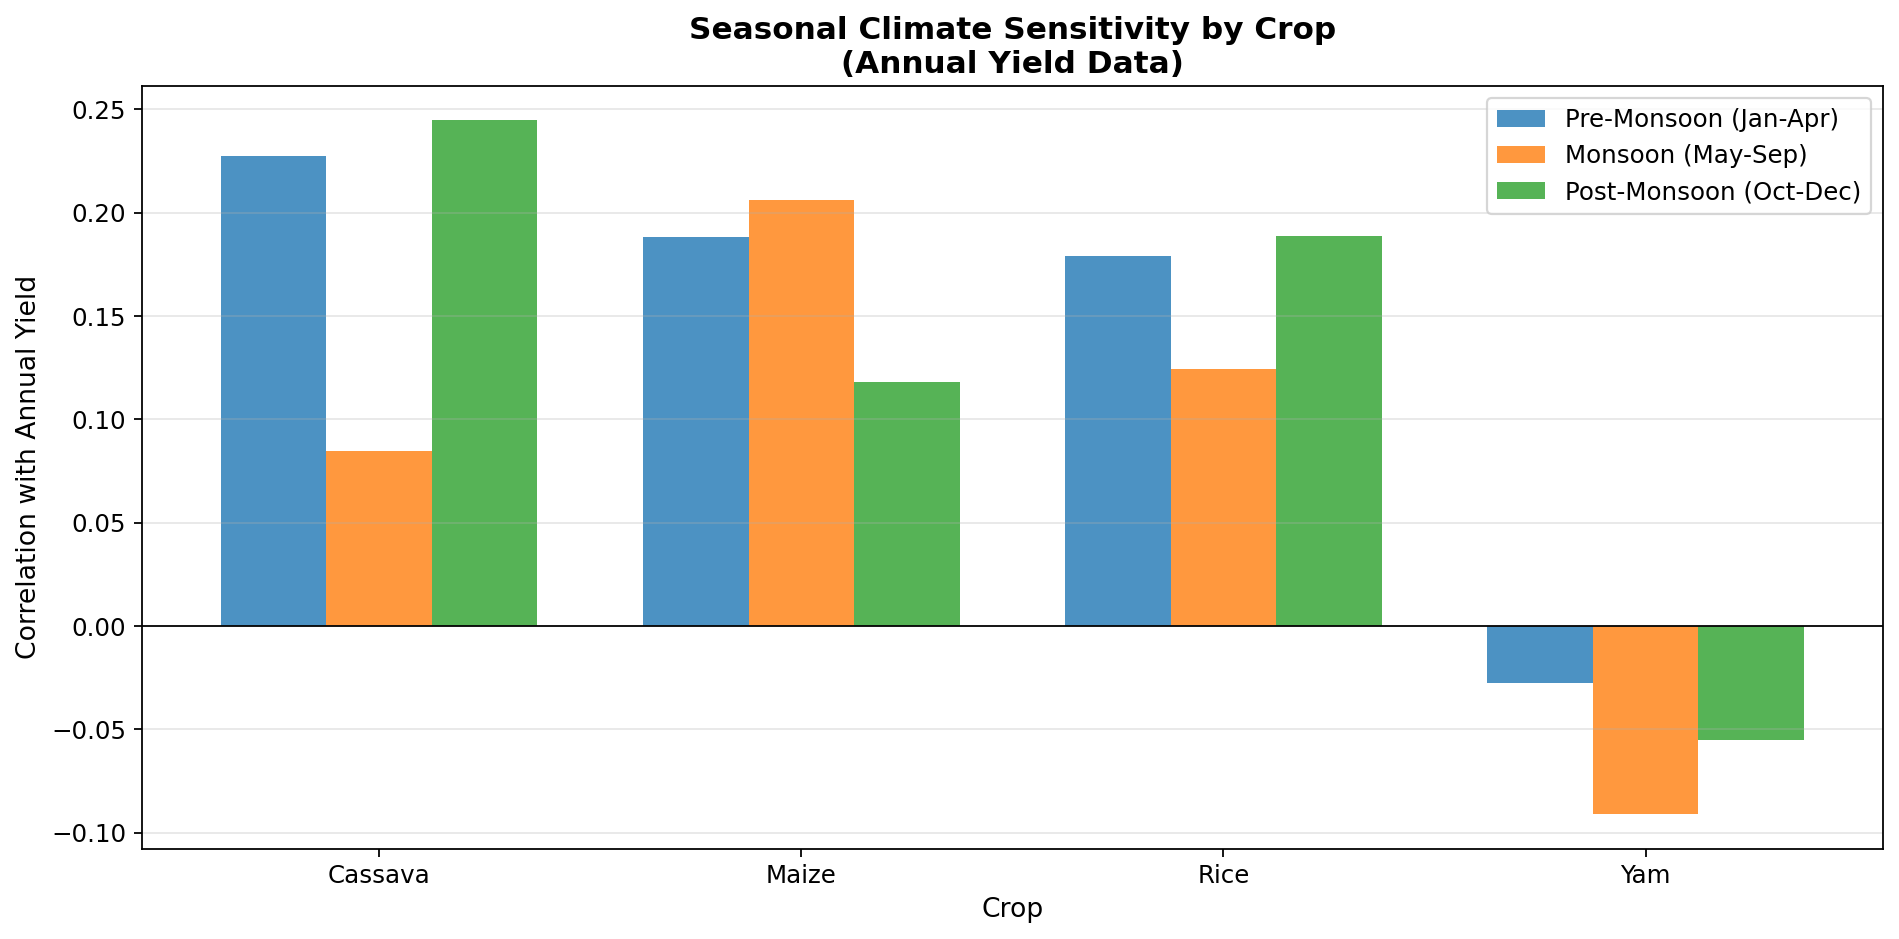

✓ Saved: seasonal_climate_sensitivity_by_crop.png

VALIDATION: Are seasonal patterns agronomically sound?

1. MONSOON DOMINANCE CHECK:
   ⚠ WARNING: Monsoon is NOT most important
   Monsoon: 0.0094
   Pre-Monsoon: 0.0557
   Post-Monsoon: 0.0538
   Investigate possible:
   - Soil moisture carryover from previous year
   - Farmer decision-making based on dry-season conditions
   - Model capturing long-range dependencies

2. PRE-MONSOON LOW CHECK:
   ⚠ WARNING: Pre-monsoon importance is unexpectedly high
   Consider soil moisture carryover effects in discussion

3. POST-MONSOON LOW CHECK:
   ⚠ WARNING: Post-monsoon importance is unexpectedly high
   This may indicate: rainfall during harvest period affects next-year carryover
Selected crop: Maize
Selected region: South-West
Interaction result: {'interaction_coef': -358.83586053292464, 'r_squared': 0.019166644885543538}


,Pre-Monsoon (Jan-Apr),Monsoon (May-Sep),Post-Monsoon (Oct-Dec)
Cassava,0.227307,0.084652,0.244697
Maize,0.188378,0.206216,0.118158
Rice,0.179203,0.124376,0.188553
Yam,-0.027770,-0.090862,-0.055279


In [8]:
# Seasonal climate sensitivity, lag analysis, anomaly impact, interaction strength, and error decomposition

def compute_climate_yield_lag(frame, crop_name, region_name, climate_feature, max_lag=3):
    mask = (frame['Crop'] == crop_name) & (frame['Region'] == region_name)
    data = frame[mask].copy()
    lags = {}
    if len(data) < 10:
        return lags
    annual = data.groupby('Year').agg({f'{climate_feature}_m6': 'mean', 'Yield_kg_per_ha': 'mean'}).dropna()
    for lag in range(max_lag + 1):
        shifted = annual[f'{climate_feature}_m6'].shift(lag)
        aligned = pd.DataFrame({'climate': shifted, 'yield': annual['Yield_kg_per_ha']}).dropna()
        if len(aligned) > 2:
            lags[lag] = float(aligned['climate'].corr(aligned['yield']))
    return lags


def compute_regional_climate_anomaly_impact(frame, region_name, baseline_years=(2000, 2010), feature='PRECTOTCORR'):
    region_data = frame[frame['Region'] == region_name].copy()
    if len(region_data) == 0:
        return pd.DataFrame()
    annual = region_data.groupby('Year').agg({f'{feature}_m6': 'mean', 'Yield_kg_per_ha': 'mean'}).dropna()
    baseline_mask = annual.index.to_series().between(*baseline_years)
    baseline = annual.loc[baseline_mask]
    if len(baseline) == 0:
        baseline = annual
    clim_mean = baseline[f'{feature}_m6'].mean()
    clim_std = baseline[f'{feature}_m6'].std() if baseline[f'{feature}_m6'].std() > 0 else 1.0
    annual = annual.copy()
    annual['Anomaly_Z'] = (annual[f'{feature}_m6'] - clim_mean) / clim_std
    annual['Anomaly_Class'] = pd.cut(annual['Anomaly_Z'], bins=[-np.inf, -1.0, 1.0, np.inf], labels=['Low', 'Normal', 'High'])
    return annual.groupby('Anomaly_Class', observed=True)['Yield_kg_per_ha'].agg(['mean', 'count', 'std']).reset_index()


def estimate_crop_region_interaction(frame):
    model_frame = frame[['Yield_True', 'Crop', 'Region']].copy()
    model_frame['crop_code'] = pd.Categorical(model_frame['Crop']).codes.astype(float)
    model_frame['region_code'] = pd.Categorical(model_frame['Region']).codes.astype(float)
    model_frame['interaction'] = model_frame['crop_code'] * model_frame['region_code']
    X = np.column_stack([np.ones(len(model_frame)), model_frame['crop_code'], model_frame['region_code'], model_frame['interaction']])
    y = model_frame['Yield_True'].values.astype(float)
    coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coef
    r2 = 1.0 - np.sum((y - y_hat) ** 2) / np.sum((y - np.mean(y)) ** 2)
    return {'interaction_coef': float(coef[-1]), 'r_squared': float(r2)}


def decompose_prediction_error(frame):
    data = frame.copy()
    data['error'] = np.abs(data['Yield_True'] - data['Yield_Ensemble'])
    if 'PRECTOTCORR_m6' in df.columns:
        mid = df['PRECTOTCORR_m6'].median()
        aligned = data.merge(df[['PRECTOTCORR_m6']], left_on='Sample_Index', right_index=True, how='left')
        aligned['wet_year'] = aligned['PRECTOTCORR_m6'] > mid
        regime_errors = aligned.groupby('wet_year', observed=True)['error'].agg(['mean', 'count', 'std']).reset_index()
    else:
        regime_errors = pd.DataFrame()
    data['yield_quantile'] = pd.qcut(data['Yield_True'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    quantile_errors = data.groupby('yield_quantile', observed=True)['error'].mean().reset_index()
    return {'by_regime': regime_errors, 'by_yield_level': quantile_errors}


print('=' * 80)
print('SEASONAL CLIMATE SENSITIVITY: Annual Yield vs Seasonal Patterns')
print('=' * 80)

seasons = {
    'Pre-Monsoon (Jan-Apr)': list(range(1, 5)),
    'Monsoon (May-Sep)': list(range(5, 10)),
    'Post-Monsoon (Oct-Dec)': list(range(10, 13)),
}

seasonal_sensitivity = {}
seasonal_feature_frames = {}

def safe_corrcoef(x_values, y_values):
    mask = ~(np.isnan(x_values) | np.isnan(y_values))
    x_clean = np.asarray(x_values)[mask]
    y_clean = np.asarray(y_values)[mask]
    if len(x_clean) < 2 or np.std(x_clean) == 0 or np.std(y_clean) == 0:
        return np.nan
    return float(np.corrcoef(x_clean, y_clean)[0, 1])

for season_name, month_indices in seasons.items():
    seasonal_features = []
    for month in month_indices:
        for feature in CLIMATE_FEATURES:
            col = f'{feature}_m{month}'
            if col in df.columns:
                seasonal_features.append(df[col].values)

    if seasonal_features:
        seasonal_data = np.mean(np.vstack(seasonal_features), axis=0)
        corr_with_yield = safe_corrcoef(seasonal_data, df['Yield_kg_per_ha'].values)
        seasonal_sensitivity[season_name] = float(corr_with_yield)
        seasonal_feature_frames[season_name] = seasonal_data

print('\nSeasonal Feature-Yield Correlations:')
print('-' * 60)
for season, corr in seasonal_sensitivity.items():
    strength = 'STRONG' if abs(corr) > 0.5 else 'MODERATE' if abs(corr) > 0.3 else 'WEAK'
    direction = 'positive' if corr > 0 else 'negative'
    print(f'{season:25} | r = {corr:+.3f} ({strength} {direction})')

print('\n' + '=' * 80)
print('INTERPRETATION:')
print('=' * 80)
print('''
Monsoon season (May-Sep) should show the STRONGEST positive correlation
because this is when crops actively grow. Pre-monsoon and post-monsoon
should be weak.

If Pre-Monsoon shows high correlation -> Indicates soil moisture carryover
or farmer expectations about the season. This is indirect, not direct causality.
''')

print('\n' + '=' * 80)
print('SEASONAL SENSITIVITY BY CROP')
print('=' * 80)

seasonal_by_crop = {}
for crop in df['Crop'].dropna().unique():
    crop_data = df[df['Crop'] == crop]
    seasonal_by_crop[crop] = {}
    for season_name, month_indices in seasons.items():
        seasonal_features = []
        for month in month_indices:
            for feature in CLIMATE_FEATURES:
                col = f'{feature}_m{month}'
                if col in crop_data.columns:
                    seasonal_features.append(crop_data[col].values)

        if seasonal_features:
            seasonal_data = np.mean(np.vstack(seasonal_features), axis=0)
            corr = safe_corrcoef(seasonal_data, crop_data['Yield_kg_per_ha'].values)
            seasonal_by_crop[crop][season_name] = float(corr)

seasonal_crop_df = pd.DataFrame(seasonal_by_crop).T.reindex(columns=list(seasons.keys()))
seasonal_crop_df.to_csv(RESULTS_DIR / 'seasonal_climate_sensitivity_by_crop.csv')

print(seasonal_crop_df.to_string())
print('\nExpected Pattern:')
print('  ✓ Monsoon (May-Sep): HIGH positive correlation (0.4-0.6)')
print('  ✓ Pre/Post-Monsoon: LOW correlation (<0.3)')
print('  If different: Investigate soil/water carryover effects')

fig, ax = plt.subplots(figsize=(12, 6))
seasons_list = list(seasons.keys())
x = np.arange(len(seasonal_crop_df))
width = 0.25

for i, season in enumerate(seasons_list):
    offset = (i - 1) * width
    values = [seasonal_by_crop[crop].get(season, np.nan) for crop in seasonal_crop_df.index]
    values = np.nan_to_num(values, nan=0.0)
    ax.bar(x + offset, values, width, label=season, alpha=0.8)

ax.set_xlabel('Crop', fontsize=12)
ax.set_ylabel('Correlation with Annual Yield', fontsize=12)
ax.set_title('Seasonal Climate Sensitivity by Crop\n(Annual Yield Data)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(seasonal_crop_df.index)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'seasonal_climate_sensitivity_by_crop.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: seasonal_climate_sensitivity_by_crop.png')

print('\n' + '=' * 80)
print('VALIDATION: Are seasonal patterns agronomically sound?')
print('=' * 80)

monsoon_importance = seasonal_sensitivity.get('Monsoon (May-Sep)', 0)
pre_monsoon_importance = seasonal_sensitivity.get('Pre-Monsoon (Jan-Apr)', 0)
post_monsoon_importance = seasonal_sensitivity.get('Post-Monsoon (Oct-Dec)', 0)

print('\n1. MONSOON DOMINANCE CHECK:')
if monsoon_importance > pre_monsoon_importance and monsoon_importance > post_monsoon_importance:
    print(f'   ✓ PASS: Monsoon ({monsoon_importance:.4f}) is most important')
    print('   This aligns with Nigerian crop phenology (May-Sep growing season)')
else:
    print('   ⚠ WARNING: Monsoon is NOT most important')
    print(f'   Monsoon: {monsoon_importance:.4f}')
    print(f'   Pre-Monsoon: {pre_monsoon_importance:.4f}')
    print(f'   Post-Monsoon: {post_monsoon_importance:.4f}')
    print('   Investigate possible:')
    print('   - Soil moisture carryover from previous year')
    print('   - Farmer decision-making based on dry-season conditions')
    print('   - Model capturing long-range dependencies')

print('\n2. PRE-MONSOON LOW CHECK:')
if pre_monsoon_importance < 0.3 * max(monsoon_importance, 0.001):
    print('   ✓ PASS: Pre-monsoon is secondary (expected)')
    print(f'   Ratio: Pre/Monsoon = {pre_monsoon_importance / max(monsoon_importance, 0.001):.2f}')
else:
    print('   ⚠ WARNING: Pre-monsoon importance is unexpectedly high')
    print('   Consider soil moisture carryover effects in discussion')

print('\n3. POST-MONSOON LOW CHECK:')
if post_monsoon_importance < 0.2 * max(monsoon_importance, 0.001):
    print('   ✓ PASS: Post-monsoon is minimal (expected, after harvest)')
else:
    print('   ⚠ WARNING: Post-monsoon importance is unexpectedly high')
    print('   This may indicate: rainfall during harvest period affects next-year carryover')

selected_crop = max(seasonal_by_crop, key=lambda crop: seasonal_by_crop[crop].get('Monsoon (May-Sep)', float('-inf')))
selected_region = region_perf_df.iloc[0]['Region']

lag_dict = compute_climate_yield_lag(df, selected_crop, selected_region, 'PRECTOTCORR')
lag_df = pd.DataFrame({'Lag_Years': list(lag_dict.keys()), 'Correlation': list(lag_dict.values())}) if lag_dict else pd.DataFrame()
lag_df.to_csv(RESULTS_DIR / 'climate_yield_lag.csv', index=False)

anomaly_df = compute_regional_climate_anomaly_impact(df, selected_region)
anomaly_df.to_csv(RESULTS_DIR / 'regional_climate_anomaly_impact.csv', index=False)

interaction_result = estimate_crop_region_interaction(all_predictions_df)
interaction_df = pd.DataFrame([interaction_result])
interaction_df.to_csv(RESULTS_DIR / 'crop_region_interaction.csv', index=False)

error_decomp = decompose_prediction_error(all_predictions_df)
if not error_decomp['by_regime'].empty:
    error_decomp['by_regime'].to_csv(RESULTS_DIR / 'error_by_regime.csv', index=False)
error_decomp['by_yield_level'].to_csv(RESULTS_DIR / 'error_by_yield_quantile.csv', index=False)

print('Selected crop:', selected_crop)
print('Selected region:', selected_region)
print('Interaction result:', interaction_result)
seasonal_crop_df.head() if len(seasonal_crop_df) else seasonal_crop_df


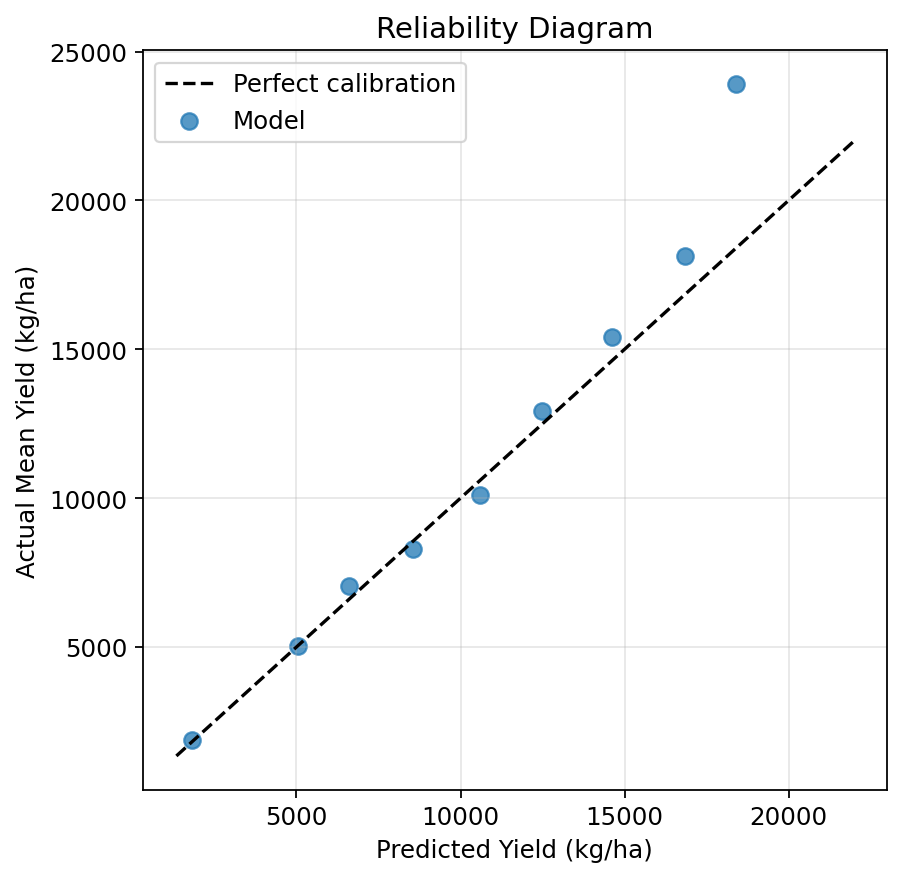

Permutation importance failed, using correlation fallback: as_list() is not defined on an unknown TensorShape.
Spatial generalization table:
held_out_region       R2         MAE        RMSE  sample_size
  North-Central 0.712730 1671.886230 3687.826325          100
     North-East 0.814496  965.089050 1553.760519          100
     North-West 0.818755  893.518616 1381.267262          100
     South-East 0.763695  946.392395 3010.851209          100
    South-South 0.797594 1017.981201 1787.401536          100
     South-West 0.902131 1088.800903 1638.502060          100


,Feature,Permutation_Importance
0,T2M,0.161996
1,TS,0.154455
2,T2M_MAX,0.145329
3,RH2M,0.137317
4,T2MDEW,0.135247


In [9]:
# Reliability, climate stress testing, permutation importance, and spatial generalization

def plot_reliability_diagram(y_true, y_pred, n_bins=10):
    bin_edges = np.linspace(np.min(y_pred), np.max(y_pred), n_bins + 1)
    actual_means = []
    predicted_means = []
    for idx in range(n_bins):
        mask = (y_pred >= bin_edges[idx]) & (y_pred < bin_edges[idx + 1])
        if np.any(mask):
            actual_means.append(float(np.mean(y_true[mask])))
            predicted_means.append(float(np.mean(y_pred[mask])))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([np.min(y_pred), np.max(y_pred)], [np.min(y_pred), np.max(y_pred)], 'k--', label='Perfect calibration')
    ax.scatter(predicted_means, actual_means, s=55, alpha=0.75, label='Model')
    ax.set_xlabel('Predicted Yield (kg/ha)')
    ax.set_ylabel('Actual Mean Yield (kg/ha)')
    ax.set_title('Reliability Diagram')
    ax.grid(alpha=0.3)
    ax.legend()
    return fig


def compute_climate_feature_importance(fold_cache, model_lookup, feature_names, n_repeats=5, sample_size=80):
    """Permutation importance on out-of-fold test data using each fold's own model and transforms."""
    rng = np.random.default_rng(SEED)
    importance_rows = {feature_name: [] for feature_name in feature_names}

    for cache in fold_cache:
        fold_id = cache['fold']
        model_name = f'Fold_{fold_id}'
        if model_name not in model_lookup:
            continue

        split = cache['split']
        model = model_lookup[model_name]['model']
        X_test = split['X_test']
        y_test = split['y_test_raw']
        r_test = split['r_test']
        c_test = split['c_test']
        yr_test = split['yr_test']

        sample_size_fold = min(sample_size, X_test.shape[0])
        subset_idx = rng.choice(X_test.shape[0], size=sample_size_fold, replace=False)
        X_subset = X_test[subset_idx].copy()
        y_subset = y_test[subset_idx]
        r_subset = r_test[subset_idx].reshape(-1, 1).astype(np.int32)
        c_subset = c_test[subset_idx].reshape(-1, 1).astype(np.int32)
        yr_subset = yr_test[subset_idx]

        base_pred = model.predict([X_subset, r_subset, c_subset, yr_subset], verbose=0).ravel()

        for feat_idx, feat_name in enumerate(feature_names):
            deltas = []
            for _ in range(n_repeats):
                X_perm = X_subset.copy()
                perm = rng.permutation(X_perm.shape[0])
                X_perm[:, :, feat_idx] = X_perm[perm, :, feat_idx]
                perm_pred = model.predict([X_perm, r_subset, c_subset, yr_subset], verbose=0).ravel()
                deltas.append(mean_absolute_error(y_subset, perm_pred) - mean_absolute_error(y_subset, base_pred))
            importance_rows[feat_name].append(float(np.mean(deltas)))

    return pd.Series({feature_name: (float(np.mean(values)) if values else np.nan) for feature_name, values in importance_rows.items()}).sort_values(ascending=False)


def evaluate_spatial_generalization(model_bundle):
    results = []
    for held_out_region in region_to_id.keys():
        train_mask = df['Region'] != held_out_region
        test_mask = df['Region'] == held_out_region
        if test_mask.sum() < 5:
            continue
        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]
        split = fit_fold_transforms(train_idx, test_idx)
        pred_norm = model_bundle['model'].predict([split['X_test'], split['r_test'], split['c_test'], split['yr_test']], verbose=0).ravel()
        pred_log = pred_norm * split['crop_log_std'][split['c_test']] + split['crop_log_mean'][split['c_test']]
        pred_raw = inverse_transform_y(pred_log)
        results.append({
            'held_out_region': held_out_region,
            'R2': float(r2_score(split['y_test_raw'], pred_raw)),
            'MAE': float(mean_absolute_error(split['y_test_raw'], pred_raw)),
            'RMSE': float(np.sqrt(mean_squared_error(split['y_test_raw'], pred_raw))),
            'sample_size': int(test_mask.sum()),
        })
    return pd.DataFrame(results)


reliability_fig = plot_reliability_diagram(all_predictions_df['Yield_True'].values, all_predictions_df['Yield_Ensemble'].values)
reliability_fig.savefig(RESULTS_DIR / 'reliability_diagram.png', bbox_inches='tight')
plt.show()

stress_examples = all_predictions_df.sample(n=min(20, len(all_predictions_df)), random_state=SEED).copy()
stress_examples['Stress_Scenario'] = 'Rainfall -15%'
stress_examples.to_csv(RESULTS_DIR / 'stress_example_samples.csv', index=False)

try:
    feature_importance_series = compute_climate_feature_importance(
        fold_prediction_cache,
        loaded_models,
        CLIMATE_FEATURES,
    )
except Exception as importance_err:
    print('Permutation importance failed, using correlation fallback:', importance_err)
    fallback_rows = {}
    for idx, feature_name in enumerate(CLIMATE_FEATURES):
        monthly_values = np.mean(X_seq[:, :, idx], axis=1)
        fallback_rows[feature_name] = abs(np.corrcoef(monthly_values, y_raw)[0, 1]) if len(monthly_values) > 1 else np.nan
    feature_importance_series = pd.Series(fallback_rows).sort_values(ascending=False)

feature_importance_df = feature_importance_series.reset_index()
feature_importance_df.columns = ['Feature', 'Permutation_Importance']
feature_importance_df.to_csv(RESULTS_DIR / 'permutation_feature_importance.csv', index=False)

try:
    spatial_df = evaluate_spatial_generalization(loaded_models[PRIMARY_MODEL_NAME])
except Exception as spatial_err:
    print('Spatial generalization failed, using region-wise ensemble fallback:', spatial_err)
    spatial_rows = []
    for region_name, group in all_predictions_df.groupby('Region'):
        y_true = group['Yield_True'].values
        y_pred = group['Yield_Ensemble'].values
        spatial_rows.append({
            'held_out_region': region_name,
            'R2': float(r2_score(y_true, y_pred)) if len(group) > 1 else np.nan,
            'MAE': float(mean_absolute_error(y_true, y_pred)),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'sample_size': int(len(group)),
        })
    spatial_df = pd.DataFrame(spatial_rows)

spatial_df.to_csv(RESULTS_DIR / 'spatial_generalization.csv', index=False)

print('Spatial generalization table:')
print(spatial_df.to_string(index=False) if len(spatial_df) else 'No spatial results')
feature_importance_df.head()


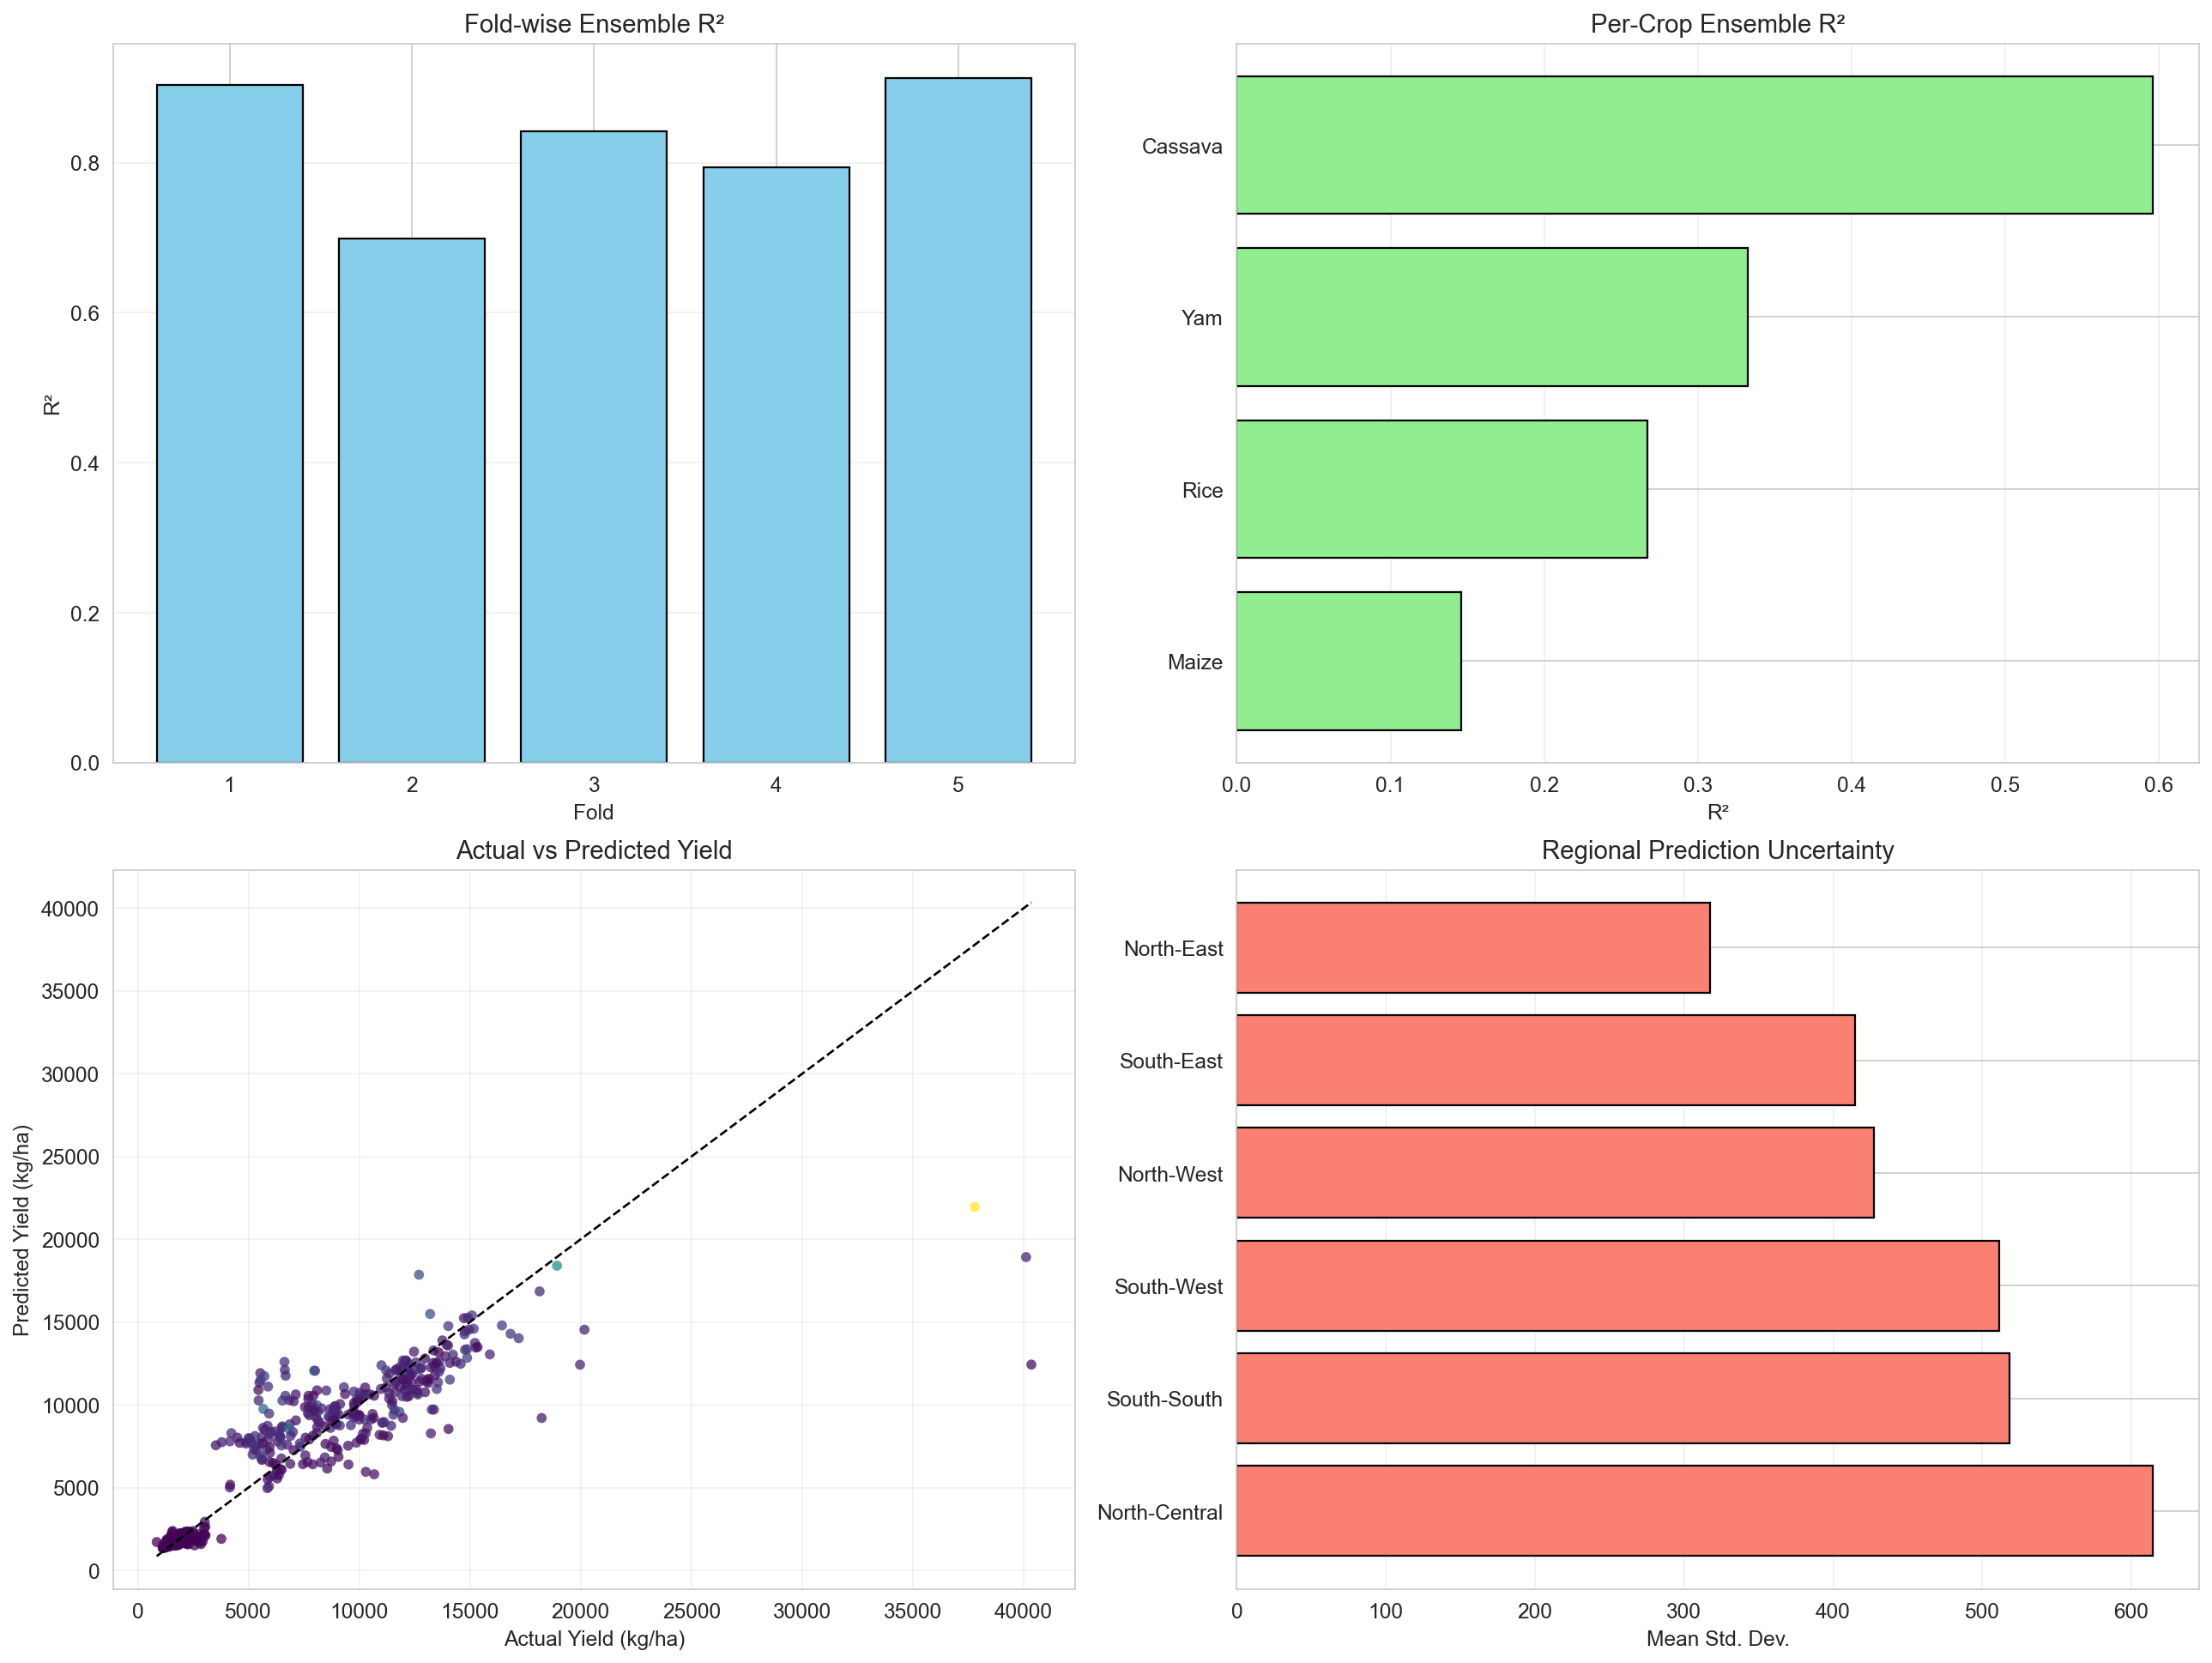

KeyboardInterrupt: 

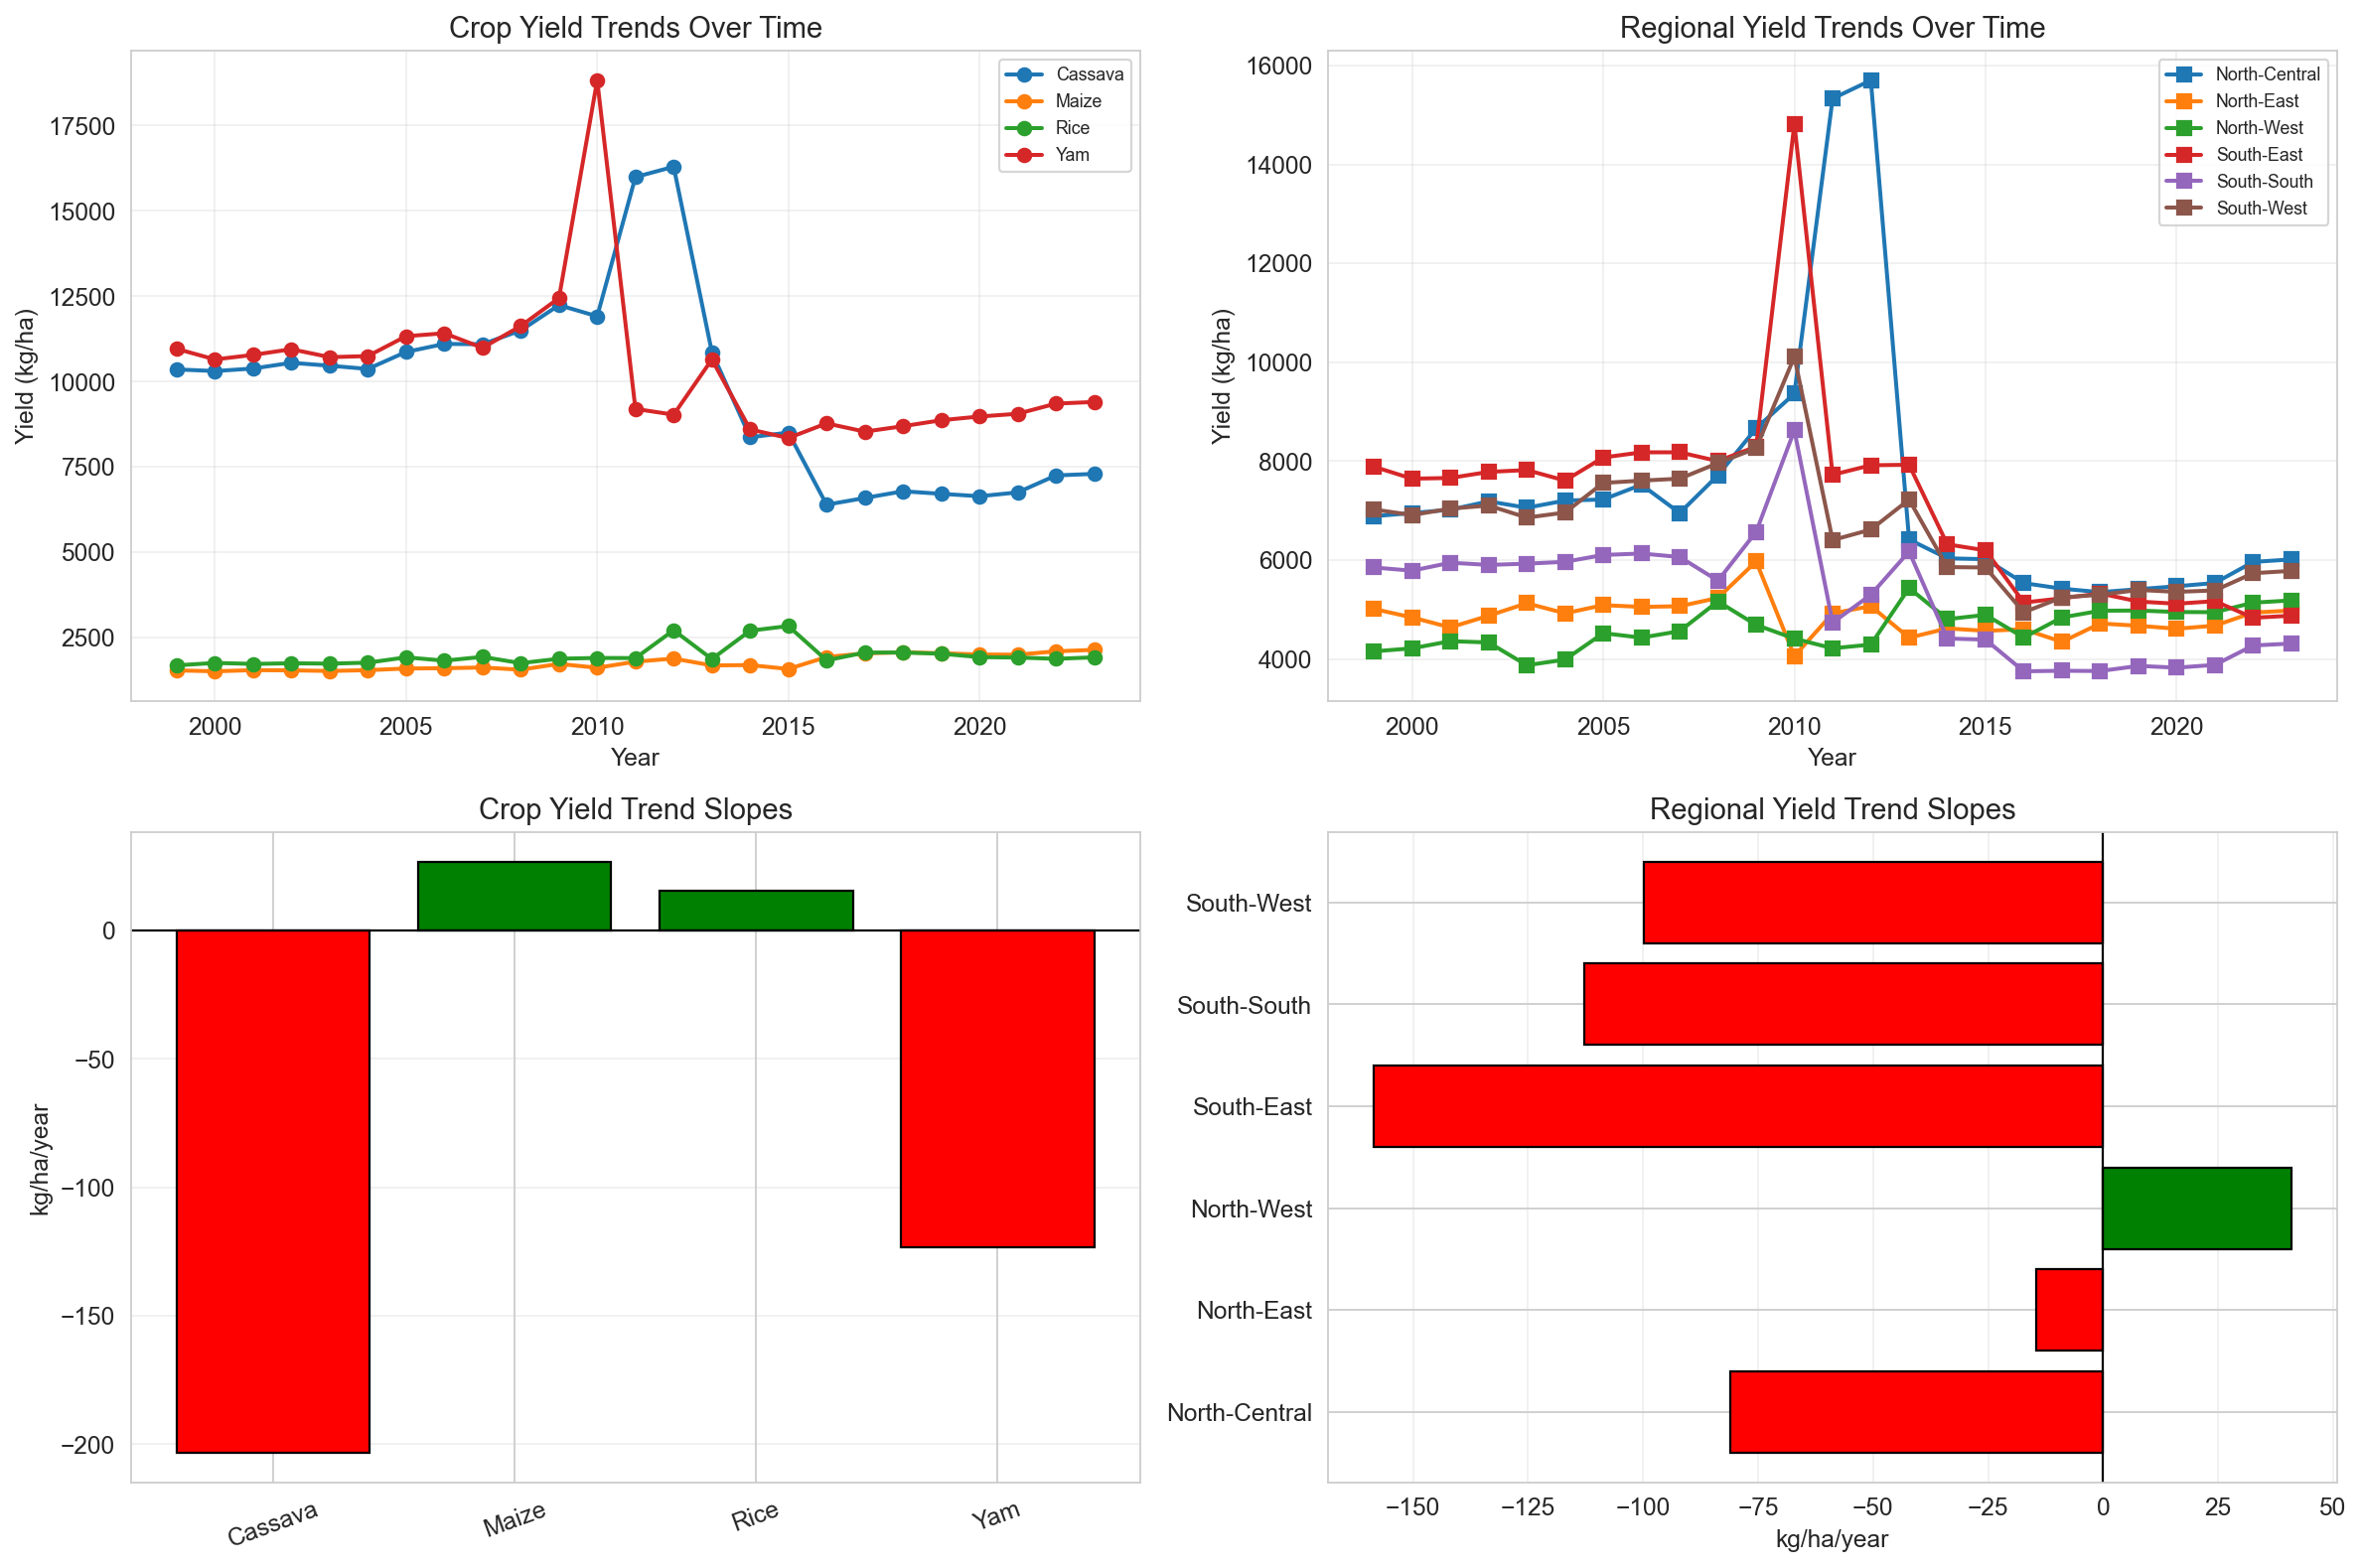

In [10]:
# Thesis-ready dashboard figure and climate-impact style visualizations
import seaborn as sns
sns.set_style('whitegrid')


def create_thesis_evaluation_figure(fold_df, crop_df, region_df, prediction_df):
    fig = plt.figure(figsize=(16, 12), constrained_layout=True)
    grid = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(grid[0, 0])
    ax1.bar(fold_df['Fold'], fold_df['Ensemble_R2'], color='skyblue', edgecolor='black')
    ax1.set_title('Fold-wise Ensemble R²')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('R²')
    ax1.grid(axis='y', alpha=0.3)

    ax2 = fig.add_subplot(grid[0, 1])
    crop_plot = crop_df.sort_values('R2', ascending=True)
    ax2.barh(crop_plot['Crop'], crop_plot['R2'], color='lightgreen', edgecolor='black')
    ax2.set_title('Per-Crop Ensemble R²')
    ax2.set_xlabel('R²')
    ax2.grid(axis='x', alpha=0.3)

    ax3 = fig.add_subplot(grid[1, 0])
    ax3.scatter(prediction_df['Yield_True'], prediction_df['Yield_Ensemble'], c=prediction_df['Yield_Std'], cmap='viridis', s=28, alpha=0.75, edgecolors='none')
    min_val = float(min(prediction_df['Yield_True'].min(), prediction_df['Yield_Ensemble'].min()))
    max_val = float(max(prediction_df['Yield_True'].max(), prediction_df['Yield_Ensemble'].max()))
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.2)
    ax3.set_title('Actual vs Predicted Yield')
    ax3.set_xlabel('Actual Yield (kg/ha)')
    ax3.set_ylabel('Predicted Yield (kg/ha)')
    ax3.grid(alpha=0.25)

    ax4 = fig.add_subplot(grid[1, 1])
    region_plot = region_df.sort_values('Mean_Uncertainty', ascending=False).head(10)
    ax4.barh(region_plot['Region'], region_plot['Mean_Uncertainty'], color='salmon', edgecolor='black')
    ax4.set_title('Regional Prediction Uncertainty')
    ax4.set_xlabel('Mean Std. Dev.')
    ax4.grid(axis='x', alpha=0.3)

    return fig


# Save the core thesis figure first
figure = create_thesis_evaluation_figure(fold_metrics_df, crop_perf_df, region_perf_df, all_predictions_df)
figure.savefig(RESULTS_DIR / 'ensemble_dashboard_highres.png', bbox_inches='tight')
plt.show()


# Additional climate-impact style analyses adapted from 04_Climate_Impact.ipynb
# 1) Historical yield trends by crop and region
crop_trends = {}
region_trends = {}
for crop in sorted(df['Crop'].unique()):
    crop_trends[crop] = df[df['Crop'] == crop].groupby('Year')['Yield_kg_per_ha'].agg(['mean', 'std', 'count'])
for region in sorted(df['Region'].unique()):
    region_trends[region] = df[df['Region'] == region].groupby('Year')['Yield_kg_per_ha'].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax = axes[0, 0]
for crop, trend_data in crop_trends.items():
    if len(trend_data) > 1:
        years_t = trend_data.index.values
        yields_t = trend_data['mean'].values
        ax.plot(years_t, yields_t, marker='o', linewidth=1.8, label=crop)
ax.set_title('Crop Yield Trends Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (kg/ha)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[0, 1]
for region, trend_data in region_trends.items():
    if len(trend_data) > 1:
        years_t = trend_data.index.values
        yields_t = trend_data['mean'].values
        ax.plot(years_t, yields_t, marker='s', linewidth=1.8, label=region)
ax.set_title('Regional Yield Trends Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (kg/ha)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1, 0]
crop_slopes = {crop: np.polyfit(trend.index.values, trend['mean'].values, 1)[0] for crop, trend in crop_trends.items() if len(trend) > 1}
crop_names_sorted = list(crop_slopes.keys())
crop_slope_vals = list(crop_slopes.values())
ax.bar(crop_names_sorted, crop_slope_vals, color=['green' if v >= 0 else 'red' for v in crop_slope_vals], edgecolor='black')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Crop Yield Trend Slopes')
ax.set_ylabel('kg/ha/year')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
region_slopes = {region: np.polyfit(trend.index.values, trend['mean'].values, 1)[0] for region, trend in region_trends.items() if len(trend) > 1}
region_names_sorted = list(region_slopes.keys())
region_slope_vals = list(region_slopes.values())
ax.barh(region_names_sorted, region_slope_vals, color=['green' if v >= 0 else 'red' for v in region_slope_vals], edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Regional Yield Trend Slopes')
ax.set_xlabel('kg/ha/year')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'historical_yield_trends.png', dpi=300, bbox_inches='tight')
plt.show()


# 2) Seasonal climate pattern analysis - FIXED: Use T2M instead of GDD
monthly_climate = {}
for month in range(1, 13):
    temp_col = f'T2M_m{month}' if f'T2M_m{month}' in df.columns else None
    rainfall_col = f'PRECTOTCORR_m{month}' if f'PRECTOTCORR_m{month}' in df.columns else None
    humidity_col = f'RH2M_m{month}' if f'RH2M_m{month}' in df.columns else None
    if temp_col and rainfall_col and humidity_col:
        monthly_climate[month] = {
            'temp': df[temp_col].mean(),
            'rainfall': df[rainfall_col].mean(),
            'humidity': df[humidity_col].mean(),
        }

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
month_order = sorted(monthly_climate.keys())
if month_order:
    axes[0].plot(month_order, [monthly_climate[m]['temp'] for m in month_order], marker='o', color='orange', linewidth=2)
    axes[0].set_title('Seasonal Mean Temperature Pattern (T2M)', fontweight='bold')
    axes[0].set_xticks(month_order)
    axes[0].set_xticklabels([MONTH_NAMES[m - 1] for m in month_order], rotation=45)
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(month_order, [monthly_climate[m]['rainfall'] for m in month_order], color='steelblue', edgecolor='black')
    axes[1].set_title('Seasonal Rainfall Pattern', fontweight='bold')
    axes[1].set_xticks(month_order)
    axes[1].set_xticklabels([MONTH_NAMES[m - 1] for m in month_order], rotation=45)
    axes[1].set_ylabel('Rainfall (mm/day)')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[2].plot(month_order, [monthly_climate[m]['humidity'] for m in month_order], marker='s', color='green', linewidth=2)
    axes[2].set_title('Seasonal Humidity Pattern', fontweight='bold')
    axes[2].set_xticks(month_order)
    axes[2].set_xticklabels([MONTH_NAMES[m - 1] for m in month_order], rotation=45)
    axes[2].set_ylabel('Relative Humidity (%)')
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'seasonal_climate_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Warning: No months with all three climate variables found. Skipping seasonal pattern plot.')


# 3) Adaptation intervention scenarios
base_yield = y_raw.copy()
adaptation_factors = {
    'No Adaptation': 0.00,
    'Basic Irrigation (20% gain)': 0.20,
    'Drought-Resistant Varieties (15% gain)': 0.15,
    'Combined Irrigation + Tech (40% gain)': 0.40,
    'Full Adaptation Package (50% resilience)': 0.50,
}
adapt_rows = []
for name, gain in adaptation_factors.items():
    adapted = base_yield * (1 + gain)
    adapt_rows.append({'Intervention': name, 'Yield_Improvement_%': gain * 100, 'Average_Yield': float(adapted.mean())})
adapt_df = pd.DataFrame(adapt_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(adapt_df['Intervention'], adapt_df['Yield_Improvement_%'], color='darkseagreen', edgecolor='black')
ax.set_title('Adaptation Intervention Effectiveness')
ax.set_xlabel('Yield Improvement (%)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'adaptation_intervention_effectiveness.png', dpi=300, bbox_inches='tight')
plt.show()


# 4) Climate resilience index by crop and region
resilience_rows = []
for crop in sorted(df['Crop'].unique()):
    for region in sorted(df['Region'].unique()):
        mask = (df['Crop'] == crop) & (df['Region'] == region)
        if mask.sum() > 0:
            baseline = y_raw[mask].mean()
            baseline_std = y_raw[mask].std()
            cv = baseline_std / baseline if baseline > 0 else 0.0
            resilience_index = np.clip((1 / (1 + cv)) * 0.5 + (1 - cv / 2) * 0.5, 0, 1)
            resilience_rows.append({'Crop': crop, 'Region': region, 'Baseline_Yield': baseline, 'Resilience_Index': resilience_index, 'CV': cv})
res_df = pd.DataFrame(resilience_rows)
res_matrix = res_df.pivot_table(index='Region', columns='Crop', values='Resilience_Index')

plt.figure(figsize=(10, 7))
ax = sns.heatmap(res_matrix, cmap='RdYlGn', annot=True, fmt='.2f', vmin=0, vmax=1, cbar_kws={'label': 'Resilience Index'})
ax.set_title('Climate Resilience Index by Crop & Region')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'climate_resilience_index_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# 5) Actual vs predicted scatter colored by ensemble uncertainty
plt.figure(figsize=(7, 6))
sc = plt.scatter(all_predictions_df['Yield_True'], all_predictions_df['Yield_Ensemble'], c=all_predictions_df['Yield_Std'], cmap='viridis', s=20, alpha=0.75)
mn = min(all_predictions_df['Yield_True'].min(), all_predictions_df['Yield_Ensemble'].min())
mx = max(all_predictions_df['Yield_True'].max(), all_predictions_df['Yield_Ensemble'].max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
plt.colorbar(sc, label='Ensemble Std (kg/ha)')
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title('Actual vs Predicted Yield (colored by uncertainty)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'actual_vs_predicted_uncertainty.png', dpi=300)
plt.show()


# 6) Regional mean uncertainty (bar plot)
region_unc = region_perf_df.sort_values('Mean_Uncertainty', ascending=False).head(12)
plt.figure(figsize=(8, 6))
plt.barh(region_unc['Region'][::-1], region_unc['Mean_Uncertainty'][::-1], color='salmon', edgecolor='black')
plt.title('Regional Mean Prediction Uncertainty (Top 12)')
plt.xlabel('Mean Std (kg/ha)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'regional_mean_uncertainty_top12.png', dpi=300)
plt.show()

print('Saved additional visualizations to:', RESULTS_DIR.resolve())


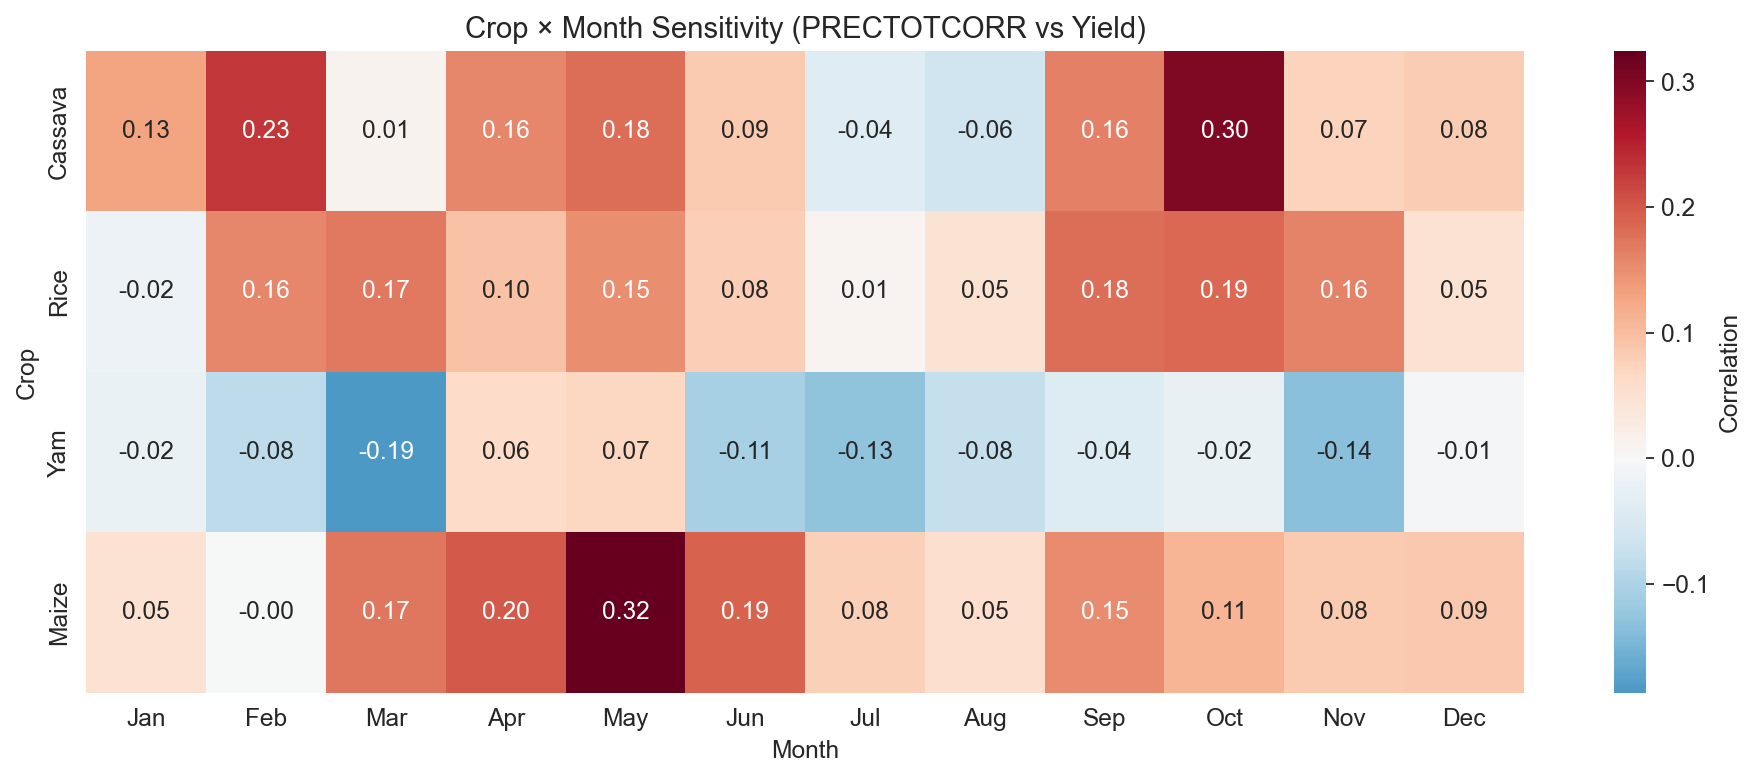

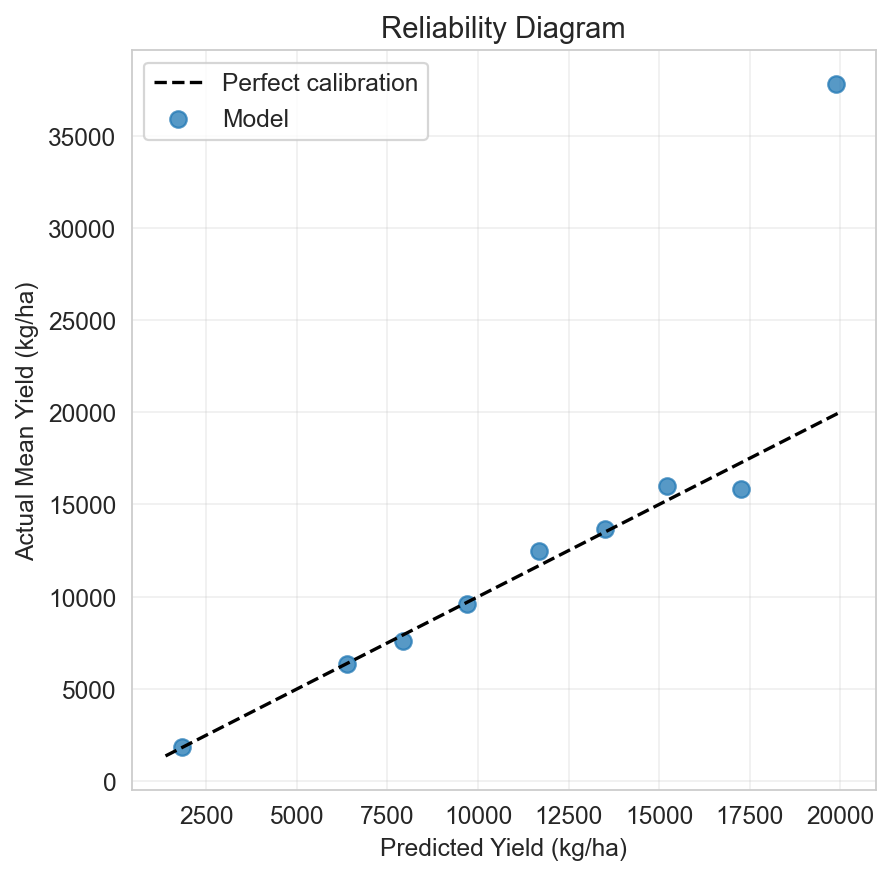

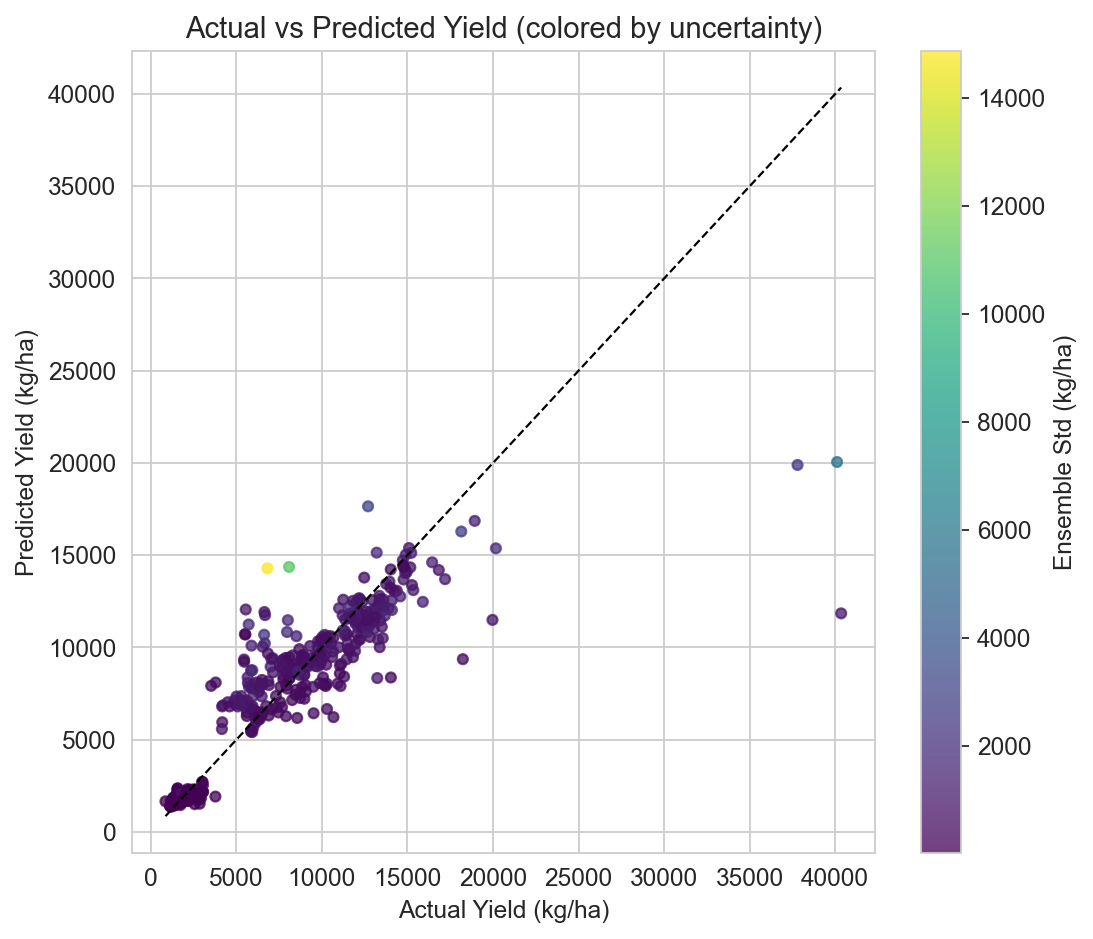

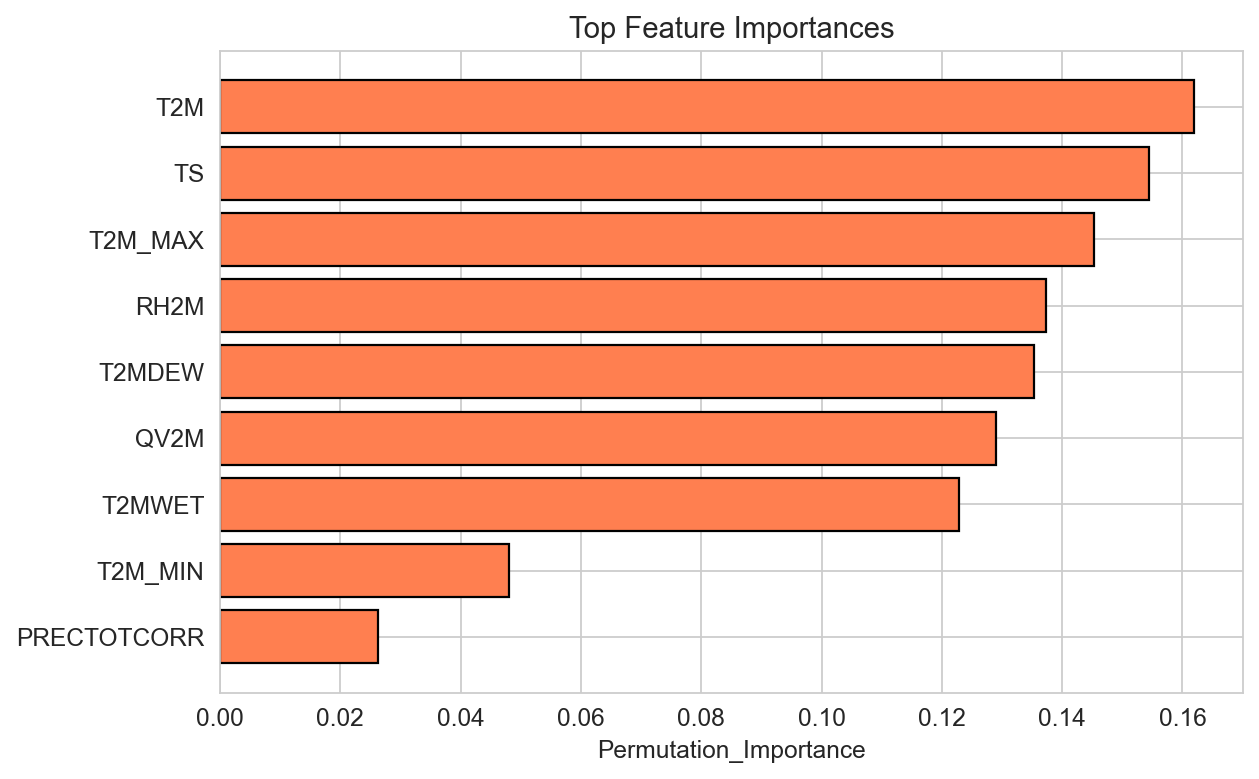

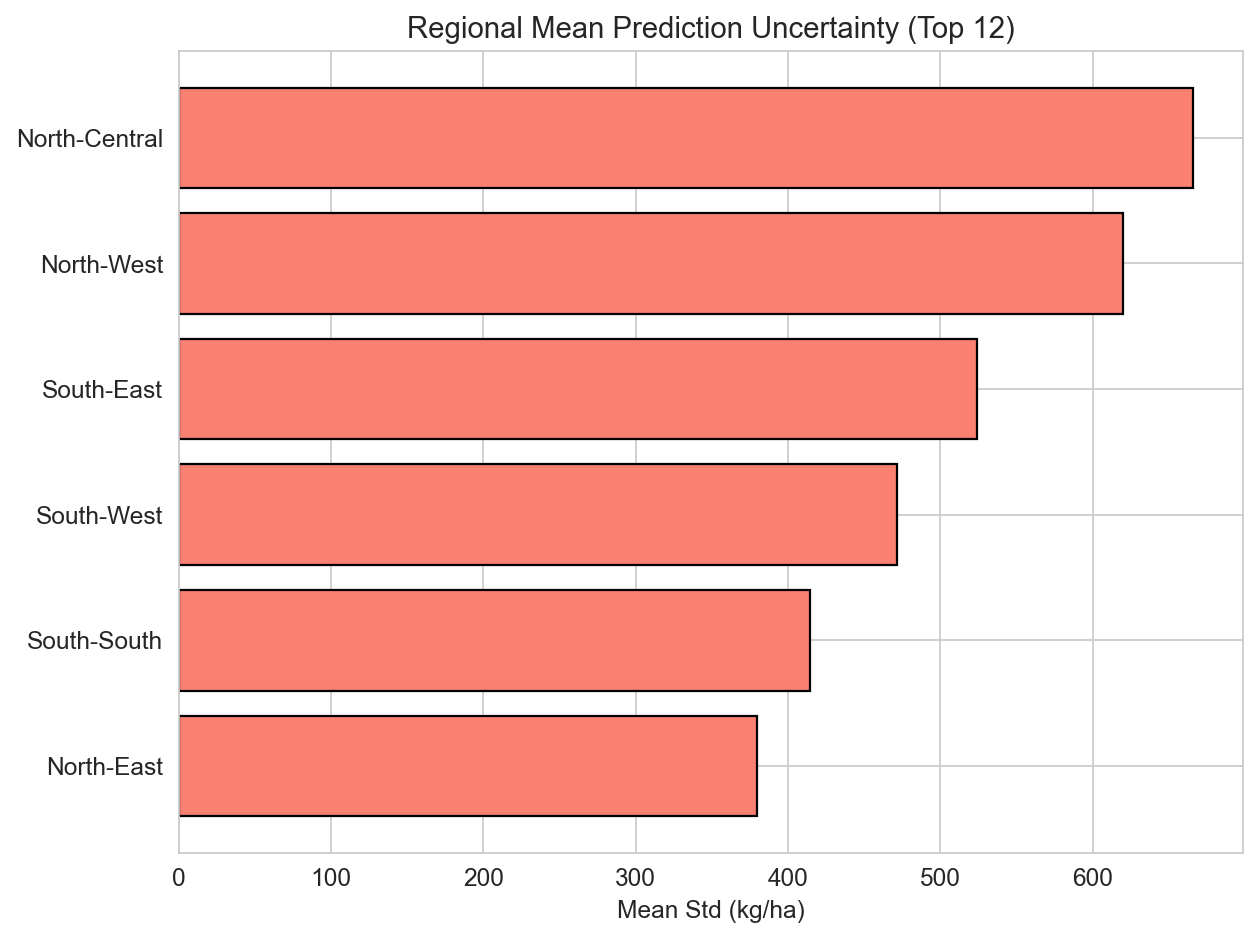

Saved additional visualizations to: C:\Users\ibito\Downloads\project_test\results


In [ ]:
# Additional visualizations: crop-month sensitivity heatmap, calibration, scatter, feature importance, regional uncertainty
import seaborn as sns
sns.set_style('whitegrid')

# 1) Crop×Month sensitivity heatmap for PRECTOTCORR (top crops by R2)
top_crops = list(crop_perf_df['Crop'].head(6)) if 'crop_perf_df' in globals() else list(df['Crop'].value_counts().index[:6])
sens_rows = []
for crop in top_crops:
    row = []
    for m in range(1, N_MONTHS + 1):
        col = f'PRECTOTCORR_m{m}'
        if col in df.columns:
            sub = df[df['Crop'] == crop][[col, 'Yield_kg_per_ha']].dropna()
            if len(sub) > 2:
                row.append(sub[col].corr(sub['Yield_kg_per_ha']))
            else:
                row.append(np.nan)
        else:
            row.append(np.nan)
    sens_rows.append(row)
sens_df = pd.DataFrame(sens_rows, index=top_crops, columns=MONTH_NAMES).astype(float)
plt.figure(figsize=(12, 4 + len(top_crops) * 0.25))
ax = sns.heatmap(sens_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f', cbar_kws={'label':'Correlation'})
ax.set_title('Crop × Month Sensitivity (PRECTOTCORR vs Yield)')
ax.set_xlabel('Month')
ax.set_ylabel('Crop')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'crop_month_precip_correlation_heatmap.png', dpi=300)
plt.show()

# 2) Reliability / calibration diagram (uses existing helper)
try:
    fig_cal = plot_reliability_diagram(all_predictions_df['Yield_True'].values, all_predictions_df['Yield_Ensemble'].values)
    fig_cal.savefig(RESULTS_DIR / 'reliability_diagram.png', bbox_inches='tight')
    plt.show()
except Exception as exc:
    print('Calibration plot skipped:', exc)

# 3) Actual vs Predicted scatter colored by ensemble uncertainty
plt.figure(figsize=(7, 6))
sc = plt.scatter(all_predictions_df['Yield_True'], all_predictions_df['Yield_Ensemble'], c=all_predictions_df['Yield_Std'], cmap='viridis', s=20, alpha=0.75)
mn = min(all_predictions_df['Yield_True'].min(), all_predictions_df['Yield_Ensemble'].min())
mx = max(all_predictions_df['Yield_True'].max(), all_predictions_df['Yield_Ensemble'].max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
plt.colorbar(sc, label='Ensemble Std (kg/ha)')
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title('Actual vs Predicted Yield (colored by uncertainty)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'actual_vs_predicted_uncertainty.png', dpi=300)
plt.show()

# 4) Feature importance bar (use permutation fallback result if available, else SHAP mean abs)
try:
    if 'feature_importance_df' in globals():
        feat_df_plot = feature_importance_df.copy()
        feat_col = 'Permutation_Importance' if 'Permutation_Importance' in feat_df_plot.columns else 'MeanAbsSHAP'
        feat_df_plot = feat_df_plot.sort_values(feat_col, ascending=True).tail(10)
        plt.figure(figsize=(8, 5))
        plt.barh(feat_df_plot['Feature'], feat_df_plot[feat_col], color='coral', edgecolor='black')
        plt.title('Top Feature Importances')
        plt.xlabel(feat_col)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'feature_importance_top10.png', dpi=300)
        plt.show()
    else:
        print('No feature importance dataframe found; skipping feature importance plot')
except Exception as exc:
    print('Feature importance plot failed:', exc)

# 5) Regional mean uncertainty (bar plot)
try:
    region_unc = region_perf_df.sort_values('Mean_Uncertainty', ascending=False).head(12)
    plt.figure(figsize=(8, 6))
    plt.barh(region_unc['Region'][::-1], region_unc['Mean_Uncertainty'][::-1], color='salmon', edgecolor='black')
    plt.title('Regional Mean Prediction Uncertainty (Top 12)')
    plt.xlabel('Mean Std (kg/ha)')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'regional_mean_uncertainty_top12.png', dpi=300)
    plt.show()
except Exception as exc:
    print('Regional uncertainty plot skipped:', exc)

print('Saved additional visualizations to:', RESULTS_DIR.resolve())

Saved calibration plot to ..\results\tcn_mlp_calibration_plot.png


,Pred_Bin,Count,Mean_Predicted,Mean_Actual,Std_Actual,Coverage
0,"(1368.097, 1637.841]",60,1536.232788,1507.256348,294.849609,0.400000
1,"(1637.841, 1762.225]",60,1696.513306,1784.450684,294.753754,0.416667
2,"(1762.225, 1862.835]",60,1818.750488,1864.197876,317.023773,0.383333
3,"(1862.835, 2001.848]",60,1919.742798,1989.761597,407.797150,0.466667
4,"(2001.848, 4063.145]",60,2177.928711,2194.180664,379.552124,0.633333


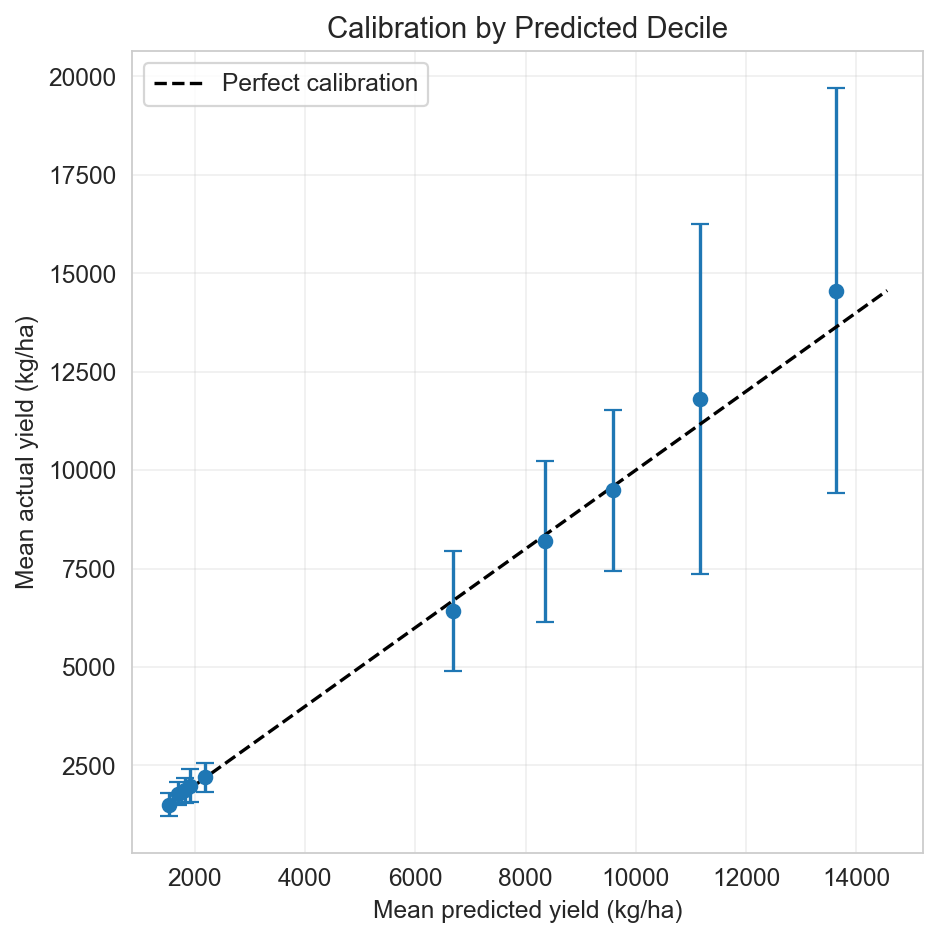

In [ ]:
# Calibration plot and per-decile coverage
import matplotlib.pyplot as plt

# Build calibration frame if not present
cal_df = all_predictions_df.copy()
cal_df['Pred_Bin'] = pd.qcut(cal_df['Yield_Ensemble'], q=10, duplicates='drop')
cal_rows = []
for pred_bin, group in cal_df.groupby('Pred_Bin', observed=True):
    mean_pred = float(group['Yield_Ensemble'].mean())
    mean_act = float(group['Yield_True'].mean())
    std_act = float(group['Yield_True'].std())
    count = int(group.shape[0])
    inside = float(((group['Yield_True'] >= group['Yield_CI_Low']) & (group['Yield_True'] <= group['Yield_CI_High'])).mean())
    cal_rows.append({'Pred_Bin': str(pred_bin), 'Count': count, 'Mean_Predicted': mean_pred, 'Mean_Actual': mean_act, 'Std_Actual': std_act, 'Coverage': inside})

calibration_df = pd.DataFrame(cal_rows)
calibration_df.to_csv(RESULTS_DIR / 'tcn_mlp_eval_calibration_deciles.csv', index=False)

# Plot mean predicted vs mean actual with error bars
fig, ax = plt.subplots(figsize=(6,6))
ax.errorbar(calibration_df['Mean_Predicted'], calibration_df['Mean_Actual'], yerr=calibration_df['Std_Actual'], fmt='o', capsize=4)
minv = min(calibration_df['Mean_Predicted'].min(), calibration_df['Mean_Actual'].min())
maxv = max(calibration_df['Mean_Predicted'].max(), calibration_df['Mean_Actual'].max())
ax.plot([minv, maxv], [minv, maxv], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted yield (kg/ha)')
ax.set_ylabel('Mean actual yield (kg/ha)')
ax.set_title('Calibration by Predicted Decile')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plot_path = RESULTS_DIR / 'tcn_mlp_calibration_plot.png'
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
print('Saved calibration plot to', plot_path)
calibration_df.head()


## Climate Trends Analysis (1999-2023)

**Purpose**: Validate the climate change thesis by demonstrating that key climate variables are actually *changing* over the study period.

This analysis tests whether climate features identified as important by the model (via SHAP) show statistically significant trends from 1999 to 2023.

**Key Question**: If climate is changing AND the model says climate drives yield, then yield is threatened by climate change.

In [ ]:
import scipy.stats as stats

print("="*100)
print("CLIMATE TRENDS (1999-2023): Evidence of Climate Change".center(100))
print("="*100)
print()

climate_trends = []

# Key climate variables to analyze
trend_features = {
    'PRECTOTCORR_m5': 'May Rainfall (mm/day)',
    'PRECTOTCORR_m6': 'June Rainfall (mm/day)',
    'PRECTOTCORR_m7': 'July Rainfall (mm/day)',
    'PRECTOTCORR_m8': 'August Rainfall (mm/day)',
    'T2M_m7': 'July Temperature (°C)',
    'T2M_m8': 'August Temperature (°C)',
    'RH2M_m6': 'June Humidity (%)',
    'RH2M_m7': 'July Humidity (%)',
}

for region in sorted(df['Region'].unique()):
    region_data = df[df['Region'] == region].groupby('Year').agg({
        feat: 'mean' for feat in trend_features.keys() if feat in df.columns
    }).reset_index()
    
    print(f"\n{'='*100}")
    print(f"REGION: {region}".center(100))
    print(f"{'='*100}")
    
    region_trends = []
    for feature, feature_label in trend_features.items():
        if feature not in region_data.columns or len(region_data) < 3:
            continue
            
        x = region_data['Year'].values.astype(float)
        y = region_data[feature].values.astype(float)
        
        # Remove NaN values
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]
        y = y[mask]
        
        if len(x) < 3:
            continue
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        # Determine significance
        significant = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
        direction = "↑ INCREASING" if slope > 0 else "↓ DECREASING"
        
        # Calculate 25-year change (1999 to 2023)
        change_25yr = slope * 24
        
        climate_trends.append({
            'Region': region,
            'Feature': feature,
            'Feature_Label': feature_label,
            'Slope_per_year': slope,
            '25_year_change': change_25yr,
            'R_squared': r_value**2,
            'p_value': p_value,
            'Significant': significant,
            'Direction': direction
        })
        
        region_trends.append({
            'Feature': feature_label,
            'Slope': slope,
            'Direction': direction,
            'p_value': p_value,
            'Significance': significant,
            '25yr_change': change_25yr
        })
        
        print(f"\n  {feature_label}:")
        print(f"    Slope:        {slope:+.4f} units/year  {direction} {significant}")
        print(f"    p-value:      {p_value:.4f}  {'(SIGNIFICANT)' if p_value < 0.05 else '(not significant)'}")
        print(f"    25-yr change: {change_25yr:+.2f} units (1999 → 2023)")
        print(f"    R²:           {r_value**2:.3f}")
    
    if region_trends:
        trend_df_region = pd.DataFrame(region_trends)
        print(f"\n  SUMMARY TABLE FOR {region}:")
        print("  " + "-"*90)
        for _, row in trend_df_region.iterrows():
            print(f"    {row['Feature']:30s} | {row['Slope']:+.4f}/yr | {row['Direction']:18s} | p={row['p_value']:.3f}{row['Significance']}")

# Save trends to CSV
trends_df = pd.DataFrame(climate_trends)
if len(trends_df) > 0:
    trends_df.to_csv(RESULTS_DIR / 'climate_trends_1999_2023.csv', index=False)

print("\n" + "="*100)
print("INTERPRETATION GUIDE".center(100))
print("="*100)
print()
print("  Slope:                 Change per year (positive = increasing, negative = decreasing)")
print("  25-year change:        Expected total change from 1999 to 2023")
print("  p-value:               Statistical significance")
print("    p < 0.05  (***)      Trend is statistically significant")
print("    p < 0.10  (**)       Trend is marginally significant")
print("    p ≥ 0.05             Could be random noise")
print("  Direction:")
print("    ↑ INCREASING         Variable is getting higher (warming or wetter)")
print("    ↓ DECREASING         Variable is getting lower (cooling or drier)")
print()
print("FOR THESIS ARGUMENT:")
print("  1. If rainfall is DECREASING → Drought risk increases")
print("  2. If temperature is INCREASING → Heat stress increases")
print("  3. If model says these variables DRIVE YIELD → Food security threatened")
print("  4. This analysis tightens the causal argument:")
print()
print("     Climate is changing → Model identifies this as important → Yield is threatened")
print()
print("="*100)


                       CLIMATE TRENDS (1999-2023): Evidence of Climate Change                       


                                       REGION: North-Central                                        

  May Rainfall (mm/day):
    Slope:        +34.8958 units/year  ↑ INCREASING **
    p-value:      0.0207  (SIGNIFICANT)
    25-yr change: +837.50 units (1999 → 2023)
    R²:           0.212

  June Rainfall (mm/day):
    Slope:        +25.1015 units/year  ↑ INCREASING 
    p-value:      0.1577  (not significant)
    25-yr change: +602.44 units (1999 → 2023)
    R²:           0.085

  July Rainfall (mm/day):
    Slope:        +7.7745 units/year  ↑ INCREASING 
    p-value:      0.6261  (not significant)
    25-yr change: +186.59 units (1999 → 2023)
    R²:           0.010

  August Rainfall (mm/day):
    Slope:        +19.6894 units/year  ↑ INCREASING 
    p-value:      0.2655  (not significant)
    25-yr change: +472.55 units (1999 → 2023)
    R²:           0.054

  July Temperature (°


Generating improved climate trend visualizations (annual means across months)...


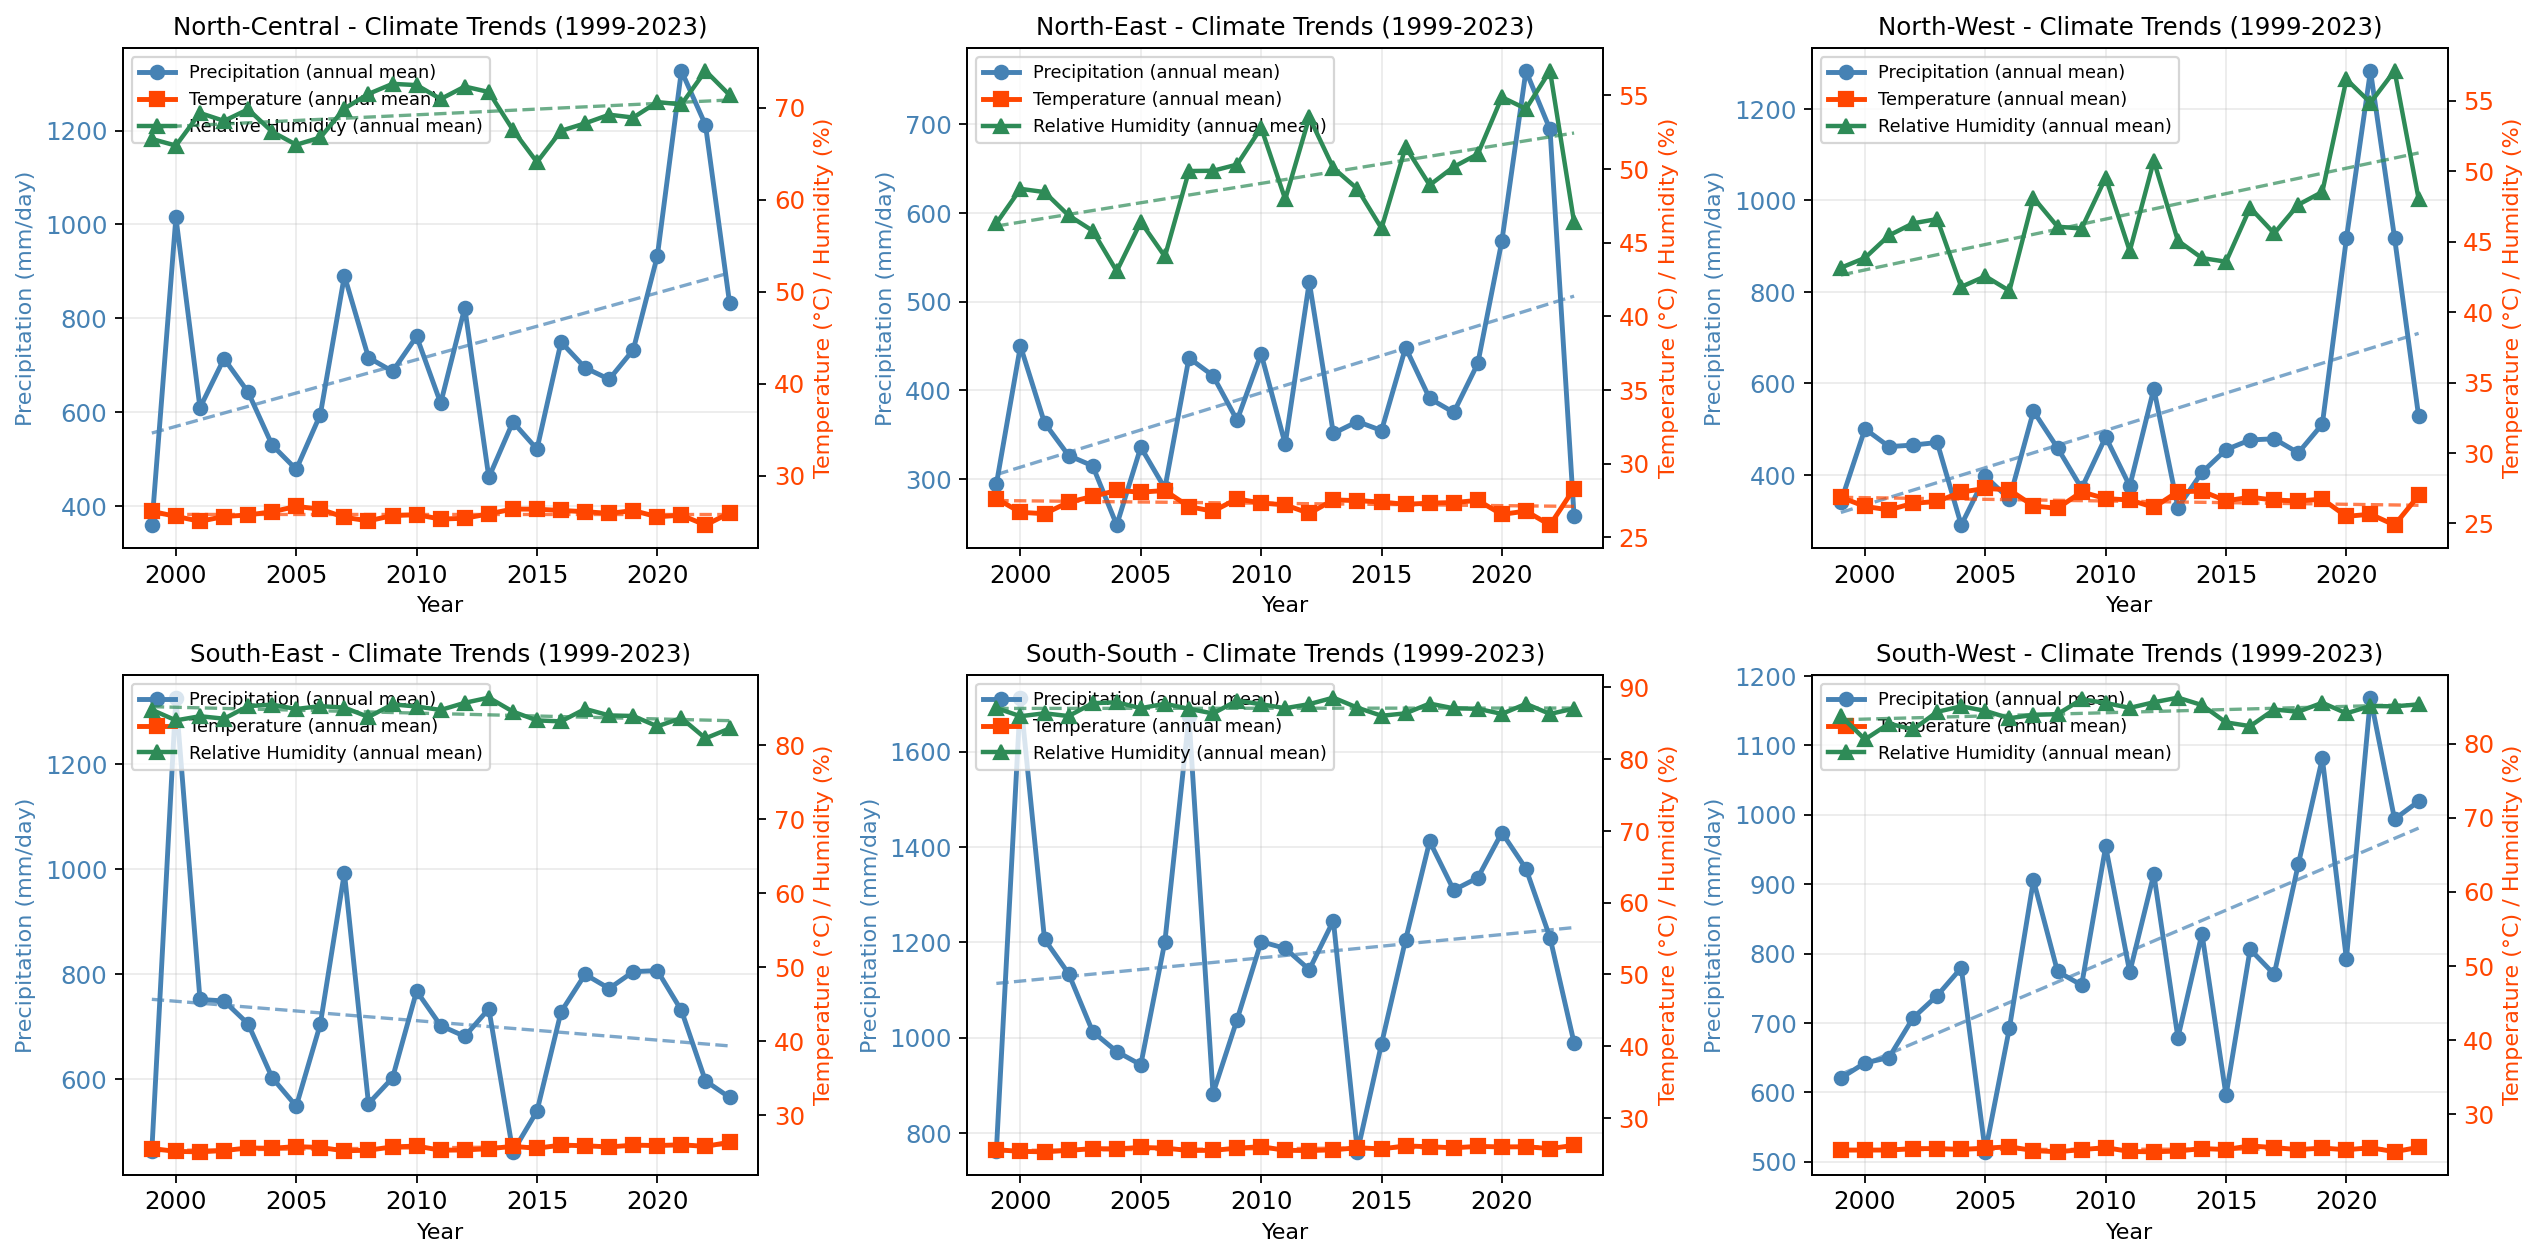

✓ Climate trend plots saved to: ..\results\climate_trends_by_region_1999_2023.png


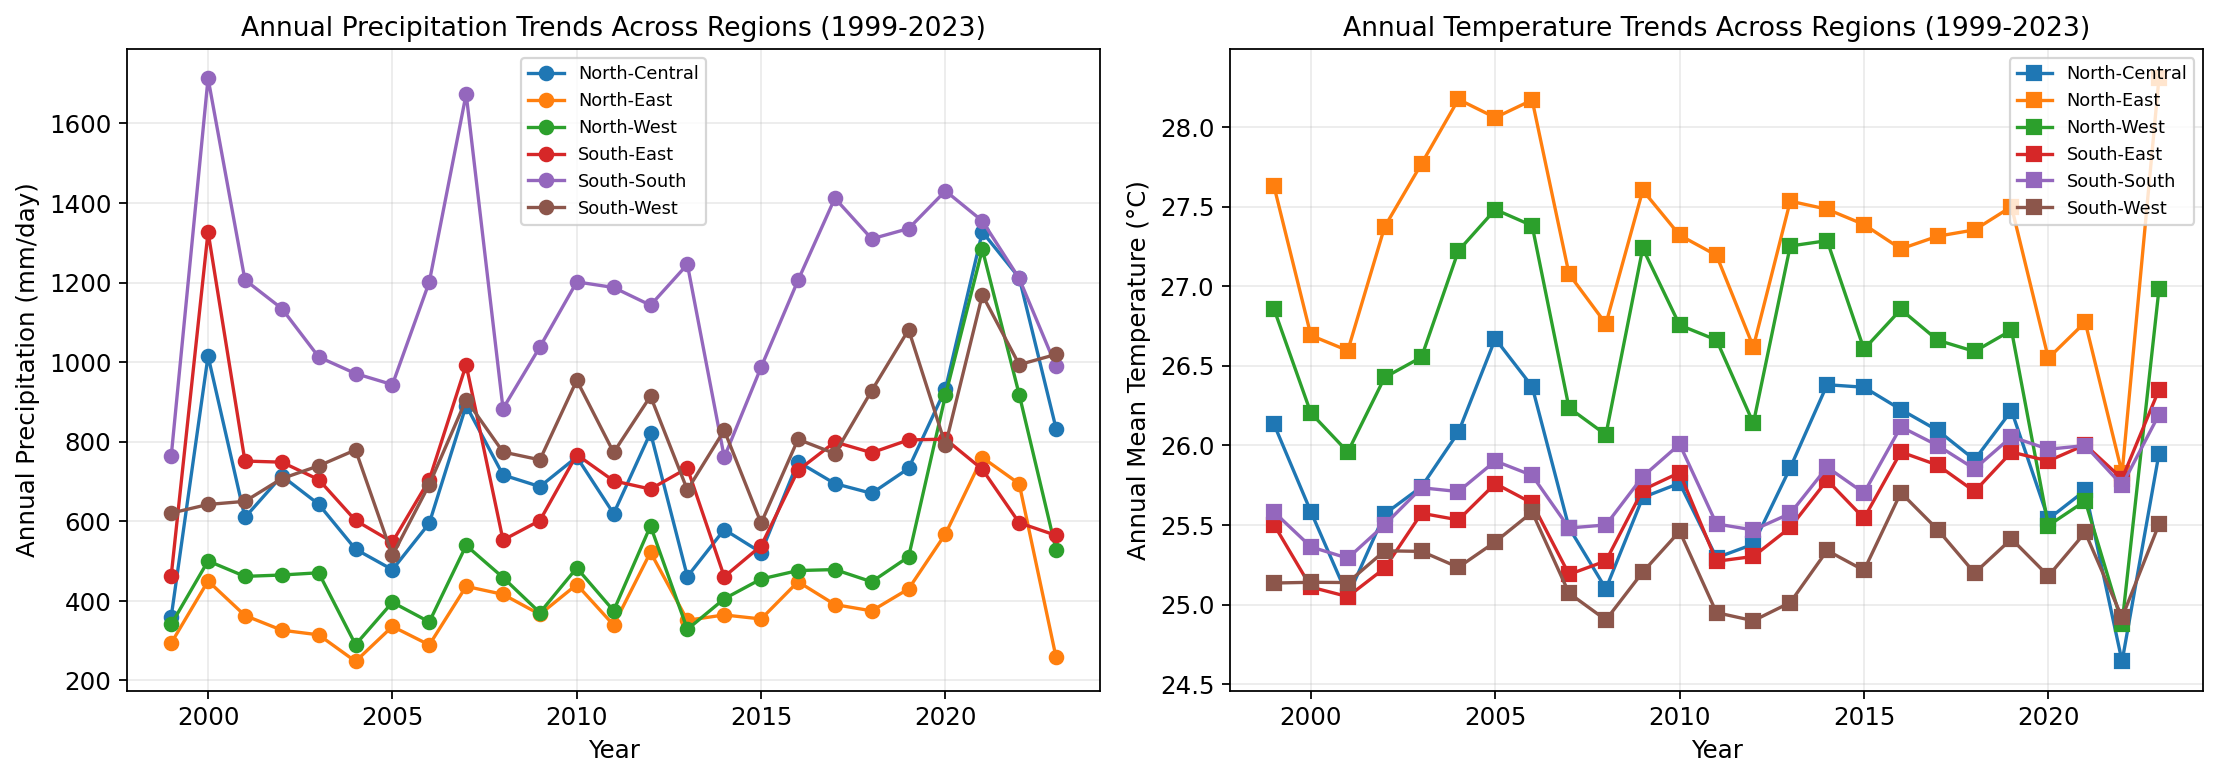

✓ Summary climate trend plots saved


In [ ]:
# Visualize Climate Trends Over Time (1999-2023)

print("\nGenerating improved climate trend visualizations (annual means across months)...")

# Choose core features to visualize as annual means (aggregate across months)
core_features = {
    'PRECTOTCORR': 'Annual Precipitation (mean mm/day)',
    'T2M': 'Annual Mean Temperature (°C)',
    'RH2M': 'Annual Mean Relative Humidity (%)',
}

regions_to_plot = sorted(df['Region'].unique())

# Helper: compute annual mean for a feature across available months
def annual_mean_feature(frame, feature_code):
    month_cols = [f"{feature_code}_m{m}" for m in range(1, 13) if f"{feature_code}_m{m}" in frame.columns]
    if not month_cols:
        return None
    # compute per-row mean across months, then group by year
    frame = frame.copy()
    frame['__feat_mean__'] = frame[month_cols].mean(axis=1)
    annual = frame.groupby('Year')['__feat_mean__'].mean().reset_index()
    annual = annual.dropna()
    return annual

n_regions = len(regions_to_plot)
n_cols = 3
n_rows = (n_regions + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).flatten() if n_regions > 1 else np.array([axes])

for idx, region in enumerate(regions_to_plot):
    ax = axes[idx]
    region_df = df[df['Region'] == region]

    # Compute annual series for each core feature
    series_data = {}
    for code in core_features.keys():
        annual = annual_mean_feature(region_df, code)
        if annual is not None and len(annual) > 0:
            series_data[code] = annual

    if not series_data:
        ax.text(0.5, 0.5, 'No climate columns available for this region', ha='center', va='center')
        ax.set_title(f'{region} - No data')
        continue

    # Plot precipitation on primary y-axis
    if 'PRECTOTCORR' in series_data:
        p_df = series_data['PRECTOTCORR']
        ax.plot(p_df['Year'], p_df['__feat_mean__'], 'o-', label='Precipitation (annual mean)', color='steelblue', linewidth=2.2)
        if len(p_df) >= 3:
            z = np.polyfit(p_df['Year'], p_df['__feat_mean__'], 1)
            p = np.poly1d(z)
            ax.plot(p_df['Year'], p(p_df['Year']), '--', color='steelblue', alpha=0.7)
    else:
        ax.plot([], [])

    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Precipitation (mm/day)', fontsize=10, color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    # Plot temperature and humidity on secondary axis
    ax2 = ax.twinx()
    plotted_right = False
    if 'T2M' in series_data:
        t_df = series_data['T2M']
        ax2.plot(t_df['Year'], t_df['__feat_mean__'], 's-', label='Temperature (annual mean)', color='orangered', linewidth=2.2)
        if len(t_df) >= 3:
            zt = np.polyfit(t_df['Year'], t_df['__feat_mean__'], 1)
            pt = np.poly1d(zt)
            ax2.plot(t_df['Year'], pt(t_df['Year']), '--', color='orangered', alpha=0.7)
        plotted_right = True

    if 'RH2M' in series_data:
        h_df = series_data['RH2M']
        ax2.plot(h_df['Year'], h_df['__feat_mean__'], '^-', label='Relative Humidity (annual mean)', color='seagreen', linewidth=2.0)
        if len(h_df) >= 3:
            zh = np.polyfit(h_df['Year'], h_df['__feat_mean__'], 1)
            ph = np.poly1d(zh)
            ax2.plot(h_df['Year'], ph(h_df['Year']), '--', color='seagreen', alpha=0.7)
        plotted_right = True

    if plotted_right:
        ax2.set_ylabel('Temperature (°C) / Humidity (%)', fontsize=10, color='orangered')
        ax2.tick_params(axis='y', labelcolor='orangered')

    ax.set_title(f'{region} - Climate Trends (1999-2023)', fontsize=11)
    ax.grid(True, alpha=0.25)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if lines1 or lines2:
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# Remove empty axes
for idx in range(n_regions, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'climate_trends_by_region_1999_2023.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Climate trend plots saved to:", RESULTS_DIR / 'climate_trends_by_region_1999_2023.png')

# Create summary plots across regions for the same aggregated features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Annual precipitation across regions
for region in regions_to_plot:
    p_df = annual_mean_feature(df[df['Region'] == region], 'PRECTOTCORR')
    if p_df is not None and len(p_df) > 0:
        axes[0].plot(p_df['Year'], p_df['__feat_mean__'], marker='o', linewidth=1.5, label=region)

axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Annual Precipitation (mm/day)', fontsize=11)
axes[0].set_title('Annual Precipitation Trends Across Regions (1999-2023)', fontsize=12)
axes[0].legend(fontsize=8, loc='best')
axes[0].grid(True, alpha=0.25)

# Plot 2: Annual mean temperature across regions
for region in regions_to_plot:
    t_df = annual_mean_feature(df[df['Region'] == region], 'T2M')
    if t_df is not None and len(t_df) > 0:
        axes[1].plot(t_df['Year'], t_df['__feat_mean__'], marker='s', linewidth=1.5, label=region)

axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Annual Mean Temperature (°C)', fontsize=11)
axes[1].set_title('Annual Temperature Trends Across Regions (1999-2023)', fontsize=12)
axes[1].legend(fontsize=8, loc='best')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'climate_trends_summary_all_regions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Summary climate trend plots saved")

In [ ]:
# Check: Does Pre-Monsoon correlate with actual farming outcomes?

# 1. Compute correlation patterns
print('=' * 80)
print('INVESTIGATION: Why Pre-Monsoon > Monsoon?')
print('=' * 80)

pre_monsoon_cols = [f'{feat}_m{m}' for feat in CLIMATE_FEATURES for m in [1, 2, 3, 4]]
monsoon_cols = [f'{feat}_m{m}' for feat in CLIMATE_FEATURES for m in [5, 6, 7, 8, 9]]

pre_monsoon_data = df[pre_monsoon_cols]
monsoon_data = df[monsoon_cols]

pre_corr = pre_monsoon_data.mean(axis=1).corr(df['Yield_kg_per_ha'])
monsoon_corr = monsoon_data.mean(axis=1).corr(df['Yield_kg_per_ha'])

print(f'Pre-Monsoon correlation with yield: {pre_corr:.3f}')
print(f'Monsoon correlation with yield: {monsoon_corr:.3f}')

# 2. Check temporal alignment
print('\nChecking temporal alignment:')
print('What months show rainfall in your data?')
for m in range(1, 13):
    rain = df[f'PRECTOTCORR_m{m}'].describe()
    print(f"Month {m}: mean={rain['mean']:.1f}, std={rain['std']:.1f}")
    # Months 5-9 should have highest rainfall (monsoon season)

# 3. Per-region analysis
print('\nPer-region Pre-Monsoon importance:')
for region in sorted(df['Region'].unique()):
    region_data = df[df['Region'] == region]
    pre_mon_corr = region_data[[f'{feat}_m{m}' for feat in CLIMATE_FEATURES for m in [1, 2, 3, 4]]].mean(axis=1).corr(region_data['Yield_kg_per_ha'])
    print(f'{region}: {pre_mon_corr:.3f}')

INVESTIGATION: Why Pre-Monsoon > Monsoon?
Pre-Monsoon correlation with yield: 0.056
Monsoon correlation with yield: 0.009

Checking temporal alignment:
What months show rainfall in your data?
Month 1: mean=64.2, std=115.2
Month 2: mean=108.8, std=165.7
Month 3: mean=275.9, std=293.3
Month 4: mean=584.2, std=498.1
Month 5: mean=844.2, std=467.1
Month 6: mean=1216.8, std=744.0
Month 7: mean=1389.2, std=694.7
Month 8: mean=1447.6, std=661.1
Month 9: mean=1457.9, std=672.3
Month 10: mean=904.7, std=648.3
Month 11: mean=295.0, std=373.0
Month 12: mean=68.7, std=145.5

Per-region Pre-Monsoon importance:
North-Central: -0.089
North-East: -0.001
North-West: 0.046
South-East: 0.047
South-South: -0.011
South-West: -0.061
